## Universidad Católica del Uruguay (UCU) - Maestría en Ciencias de Datos 
### Trabajo Final - Aprendizaje Automático (ML)
#### Equipo: Lucas Barrios, Esteban Cardozo, Enrique De Martini

## 0) Importación de librerías y datos

In [1]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
import sklearn
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import roc_auc_score, make_scorer, confusion_matrix, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.base import clone
from sklearn.feature_selection import RFECV
from scipy import sparse

In [ ]:
print("Cargando datasets desde INEEd...")
url_cxto = "https://www.ineed.edu.uy/wp-content/uploads/2023/08/Datos_Estudiante_CXTO.csv"
url_socio = "https://www.ineed.edu.uy/wp-content/uploads/2023/08/Datos_Estudiante_Socioemocional.csv"

# Se agrega el parámetro encoding='latin-1' y decimal=','
df_cxto = pd.read_csv(url_cxto, sep=';', encoding='latin-1', decimal=',')
df_socio = pd.read_csv(url_socio, sep=';', encoding='latin-1', decimal=',')

# Unir los dataframes preservando el padrón completo de contexto.
# Se usa outer join para que los estudiantes que no tienen datos socioemocionales también se incluyan en el análisis.
cols_socio_nuevas = df_socio.columns.difference(df_cxto.columns).tolist() + ["AlumnoCodigoDes"]
df_merged = df_cxto.merge(df_socio[cols_socio_nuevas], on="AlumnoCodigoDes", how="outer")

Cargando datasets desde INEEd...


## 1) Reajuste de pesos

En esta parte del flujo se construye el peso final que se utilizará para las observaciones que sí cuentan con resultado de matemática. La idea es corregir el posible sesgo de selección que aparece cuando no todos los estudiantes tienen la misma probabilidad de haber rendido la prueba.

1. Se define una variable de participación:
   $$R_i = \begin{cases}
   1, & \text{si el estudiante } i \text{ rindió la prueba de matemática} \\
   0, & \text{si no la rindió}
   \end{cases}$$
   Esta variable se calcula observando los NaNs de **_Niveles_MAT_**
2. Sobre todo el padrón completo se estima una probabilidad de participación mediante un modelo de propensión.
   Para esto se calculan por grupo, las proporciones de estudiantes que efectivamente rindieron la prueba:
   $$\hat{p}_i = \frac{R_g}{Total_g}$$

   Siendo $\hat{p}_i$ la probabilidad del estudiante $i$ de haber realizado la prueba, $R_g$ la cantidad de estudiantes de un grupo $g$ que rindieron la prueba, y $Total_g$ la cantitidad de estudiantes que figuran administrativamente como inscriptos en el grupo $g$. Para este cálculo se utiliza la variable **_GrupoCodigoDes_** que es el identificador único de los grupos de estudiantes. 

3. Para las observaciones que sí tienen resultado de matemática, el peso original de la encuesta se ajusta dividiendo por esa probabilidad estimada:
   $$w_i^{adj} = \frac{w_i^{orig}}{\hat{p}_i}$$
   Esto compensa el hecho de que los estudiantes con menor probabilidad de rendir la prueba tienen menos representación en la muestra observada.

4. Para evitar que los pesos se vuelvan excesivamente grandes cuando $\hat{p}_i$ es muy pequeño, se impone un piso de estabilidad:
   $$\hat{p}_i \leftarrow \max(\hat{p}_i, 0.05)$$

5. Finalmente, se normaliza el total de los pesos ajustados para que la suma siga siendo coherente con el total del padrón original:
   $$\text{factor de normalización} = \frac{\sum_j w_j^{orig}}{\sum_{k:R_k=1} w_k^{adj}}$$
   y por lo tanto:
   $$w_i^{final} = \text{factor de normalización} \cdot w_i^{adj}$$

En resumen, el procedimiento busca reponderar las observaciones observadas para que representen mejor a la población total, aun cuando no todos los estudiantes cuentan con resultado de matemática.

### 1.1) Cálculo de pesos ajustados

In [3]:

print("Calculando pesos de propensión con probabilidad directa por grupo...")

# Desfragmentar el DataFrame antes de agregar nuevas columnas
# Pandas consolida todo en un solo bloque de memoria mejorando performance de acceso y escritura.
df_merged = df_merged.copy()

# Definir variable objetivo R
# R = 1 si el estudiante rindió la prueba de matemática; 0 en caso contrario
df_merged['R'] = df_merged['Niveles_MAT'].notna().astype(int)

print(f"Observaciones en el padrón completo: {len(df_merged)}")
print(f"Observaciones con MAT disponible: {df_merged['R'].sum()}")

# Calcular probabilidad de participación directa por grupo
# p_hat(grupo) = fracción de estudiantes del grupo que rindieron la prueba
prob_participacion_grupo = (
    df_merged.groupby('GrupoCodigoDes', dropna=False)['R'].mean()
)

# Asignar a cada estudiante la probabilidad de su grupo
df_merged['p_hat'] = df_merged['GrupoCodigoDes'].map(prob_participacion_grupo)

# Weight Trimming: limitamos probabilidad mínima a 0.01
# Esto evita que pesos muy grandes aparezcan cuando p_hat es muy bajo.
df_merged['p_hat'] = df_merged['p_hat'].clip(lower=0.01)

# Filtrar el dataset final y calcular pesos ajustados
# Solo las observaciones que sí tienen calificación en matemática serán usadas
# posteriormente en el modelo de aprendizaje. Para ellas, el peso original se ajusta
# dividiendo por la probabilidad estimada de haber realizado la prueba.
df_final = df_merged[df_merged['R'] == 1].copy()
df_final['peso_ajustado'] = df_final['peso_MEst'] / df_final['p_hat']

# Normalización
# El objetivo es que la suma de los pesos ajustados siga siendo consistente con
# el total del padrón original, preservando la representatividad poblacional.
suma_peso_original_total = df_merged['peso_MEst'].sum()
suma_peso_ajustado = df_final['peso_ajustado'].sum()

factor_normalizacion = suma_peso_original_total / suma_peso_ajustado
df_final['peso_final_MAT'] = df_final['peso_ajustado'] * factor_normalizacion

# Verificación
print("-" * 50)
print(f"Observaciones iniciales (padron total): {len(df_merged)}")
print(f"Observaciones finales (solo test MAT): {len(df_final)}")
print(f"Suma de pesos original: {suma_peso_original_total:.2f}")
print(f"Suma de pesos ajustados: {df_final['peso_final_MAT'].sum():.2f}")
print("-" * 50)

Calculando pesos de propensión con probabilidad directa por grupo...
Observaciones en el padrón completo: 11546
Observaciones con MAT disponible: 9539
--------------------------------------------------
Observaciones iniciales (padron total): 11546
Observaciones finales (solo test MAT): 9539
Suma de pesos original: 11546.00
Suma de pesos ajustados: 11546.00
--------------------------------------------------


### 1.2) Construcción de dataframes de trabajo (X, y, w)

In [4]:
# Diccionario para mapear las variables predictoras
mapa_variables = {

    # =========================================================
    # DATASET: CXTO (Datos de Contexto y Diseño Muestral)
    # =========================================================
    
    # --- Variables Demográficas y Geográficas ---
    "MdeoInt"               : "zona",
    "regiones"              : "region",
    "EF46m"                 : "departamento_residencia",
    "categoria_centro"      : "categoria_centro",
    "categoria_grupo"       : "categoria_grupo",
    "AlumnoGenero"          : "alumno_genero",
    "EF2d"                  : "ascendencia",
    "EF2b"                  : "pais_nacimiento",
    "EDAD"                  : "edad",
    
    # --- Índices de Estatus Económico y Social ---
    "INSE"                  : "idx_inse_alumno",
    "ESCS_Alumno"           : "idx_esec_alumno",
    "ESCS_Centro"           : "idx_esec_centro",
    "ESCS_Grupo"            : "idx_esec_grupo",

    # =========================================================
    # DATASET: SOCIO (Cuestionario Socioemocional)
    # =========================================================
    # --- Índices de Contexto y Actitudes ---
    "ESTSENTPER_E_ESC50"    : "idx_sentido_pertenencia",
    "VINCENTREEST_E_ESC50"  : "idx_vinculo_entre_estudiantes",
    "VINESTADS_E_ESC50"     : "idx_vinculo_estudiantes_adscriptos",
    "VINESTPROF_E_ESC50"    : "idx_vinculo_estudiantes_docentes",
    "VOZESTU_E_ESC50"       : "idx_voz_estudiante",
    "ACTITUDLEC_E_ESC50"    : "idx_actitud_lectura",
    "ACTITUDMAT_E_ESC50"    : "idx_actitud_matematica",
    
    # --- Índices de Habilidades Socioemocionales y Cognitivas ---
    "AUTOCON_E_ESC50"       : "idx_autocontrol",
    "AUTOEIDE_E_ESC50"      : "idx_autoeficacia_idioma_espanol",
    "AUTOEMAT_E_ESC50"      : "idx_autoeficacia_matematica",
    "AUTOMETA_E_ESC50"      : "idx_autoregulacion_metacognitiva",
    "EMPATIA_E_ESC50"       : "idx_empatia",
    "EXTERNALIZ_E_ESC50"    : "idx_conductas_externalizantes",
    "HABINTER_E_ESC50"      : "idx_habilidades_interpersonales",
    "HABINTRA_E_ESC50"      : "idx_habilidades_intrapersonales",
    "HABRELAC_E_ESC50"      : "idx_habilidades_relacionamiento",
    "INTERNALIZ_E_ESC50"    : "idx_conductas_internalizantes", 
    "MOTAUTREGA_E_ESC50"    : "idx_motivacion_aprendizaje",
    "MOTINT_E_ESC50"        : "idx_motivacion_intrinseca",
    "PERSAC_E_ESC50"        : "idx_perseverancia_academica",
    "REGEMO_E_ESC50"        : "idx_regulacion_emocional",
    "VALTIDE_E_ESC50"       : "idx_valoracion_tarea_idioma_espanol",
    "VALTMAT_E_ESC50"       : "idx_valoracion_tarea_matematica"
}

# Renombrar columnas. Como evitamos los sufijos _x/_y, las variables originales están intactas.
df_final = df_final.rename(columns=mapa_variables)

# Crear dataset X asegurando que SOLO contiene las variables mapeadas
variables_modelo = list(mapa_variables.values())
X = df_final[variables_modelo].copy()

# Reemplazar códigos numéricos de "No sabe / No contesta" por nulos reales (NaN)
# tanto en ascendencia como en otras variables sociodemográficas
X = X.replace({99: np.nan, 98: np.nan, "99": np.nan, "98": np.nan})

# Construir la variable objetivo binaria
# 1 (satisfactorio) = N4 o N5; 0 (insatisfactorio) = B1, N1, N2 o N3
y = np.where(df_final["Niveles_MAT"].isin(["N4", "N5"]), 0, 1)

# Construir el vector de pesos muestrales
w = df_final["peso_final_MAT"].values

X.head()

,zona,region,departamento_residencia,categoria_centro,categoria_grupo,alumno_genero,ascendencia,pais_nacimiento,edad,idx_inse_alumno,...,idx_habilidades_interpersonales,idx_habilidades_intrapersonales,idx_habilidades_relacionamiento,idx_conductas_internalizantes,idx_motivacion_aprendizaje,idx_motivacion_intrinseca,idx_perseverancia_academica,idx_regulacion_emocional,idx_valoracion_tarea_idioma_espanol,idx_valoracion_tarea_matematica
1,Montevideo,SUR,1.0,Secundaria pública,Secundaria pública,F,1.0,1.0,14.0,60.0,...,40.019059,69.656611,41.010622,43.076212,49.324112,50.790349,50.096625,67.585754,43.166604,47.914845
2,Montevideo,SUR,1.0,Secundaria pública,Secundaria pública,M,1.0,1.0,15.0,43.0,...,63.225628,66.003117,56.617639,40.006934,63.639945,57.736057,60.045572,64.311434,63.849964,57.257982
3,Interior,ESTE,10.0,UTU,UTU-CBT,F,2.0,1.0,16.0,67.0,...,49.992868,37.121897,52.789488,47.602197,49.654560,48.935145,48.679999,36.336460,50.561581,46.082428
4,Montevideo,SUR,1.0,Secundaria pública,Secundaria pública,M,5.0,1.0,15.0,47.0,...,64.027718,61.606093,61.935990,50.966593,47.718295,51.606241,55.235810,62.415437,41.441242,37.498478
5,Montevideo,SUR,2.0,Secundaria pública,Secundaria pública,M,2.0,1.0,15.0,36.0,...,49.877965,55.080191,41.589851,54.244805,52.724155,52.407091,48.326806,54.561106,58.436834,55.303599


## 2) Análisis exploratorio de datos (EDA)

### 2.1) Auditoría de datos

In [5]:
df_final_modelo = df_final[variables_modelo].copy()
df_final_modelo['target'] = y

print("AUDITORIA DE VARIABLES DEL DATASET df_final_modelo")

print(f"\nDimensiones del dataset: {df_final_modelo.shape[0]} filas × {df_final_modelo.shape[1]} columnas\n")

audit = pd.DataFrame({
    'dtype':          df_final_modelo.dtypes,
    'nulos':          df_final_modelo.isnull().sum(),
    'pct_nulos':      (df_final_modelo.isnull().sum() / len(df_final_modelo) * 100).round(2),
    'valores_únicos': df_final_modelo.nunique(),
    'moda':           df_final_modelo.mode().iloc[0], # Extrae la primera fila de la moda
    'ejemplo':        df_final_modelo.sample(1).iloc[0], # Genera muestra aleatoria y extrae primera fila
    })
audit

AUDITORIA DE VARIABLES DEL DATASET df_final_modelo

Dimensiones del dataset: 9539 filas × 37 columnas



,dtype,nulos,pct_nulos,valores_únicos,moda,ejemplo
zona,object,0,0.00,2,Interior,Interior
region,object,0,0.00,5,SUR,CENTRO
departamento_residencia,float64,612,6.42,20,1.0,6.0
categoria_centro,object,0,0.00,3,Secundaria pública,Secundaria pública
categoria_grupo,object,0,0.00,4,Secundaria pública,Secundaria pública
alumno_genero,object,93,0.97,3,M,M
ascendencia,float64,612,6.42,6,1.0,2.0
pais_nacimiento,float64,612,6.42,10,1.0,1.0
edad,float64,271,2.84,16,15.0,16.0
idx_inse_alumno,float64,633,6.64,80,39.0,35.0


### 2.2) Barplots categóricos

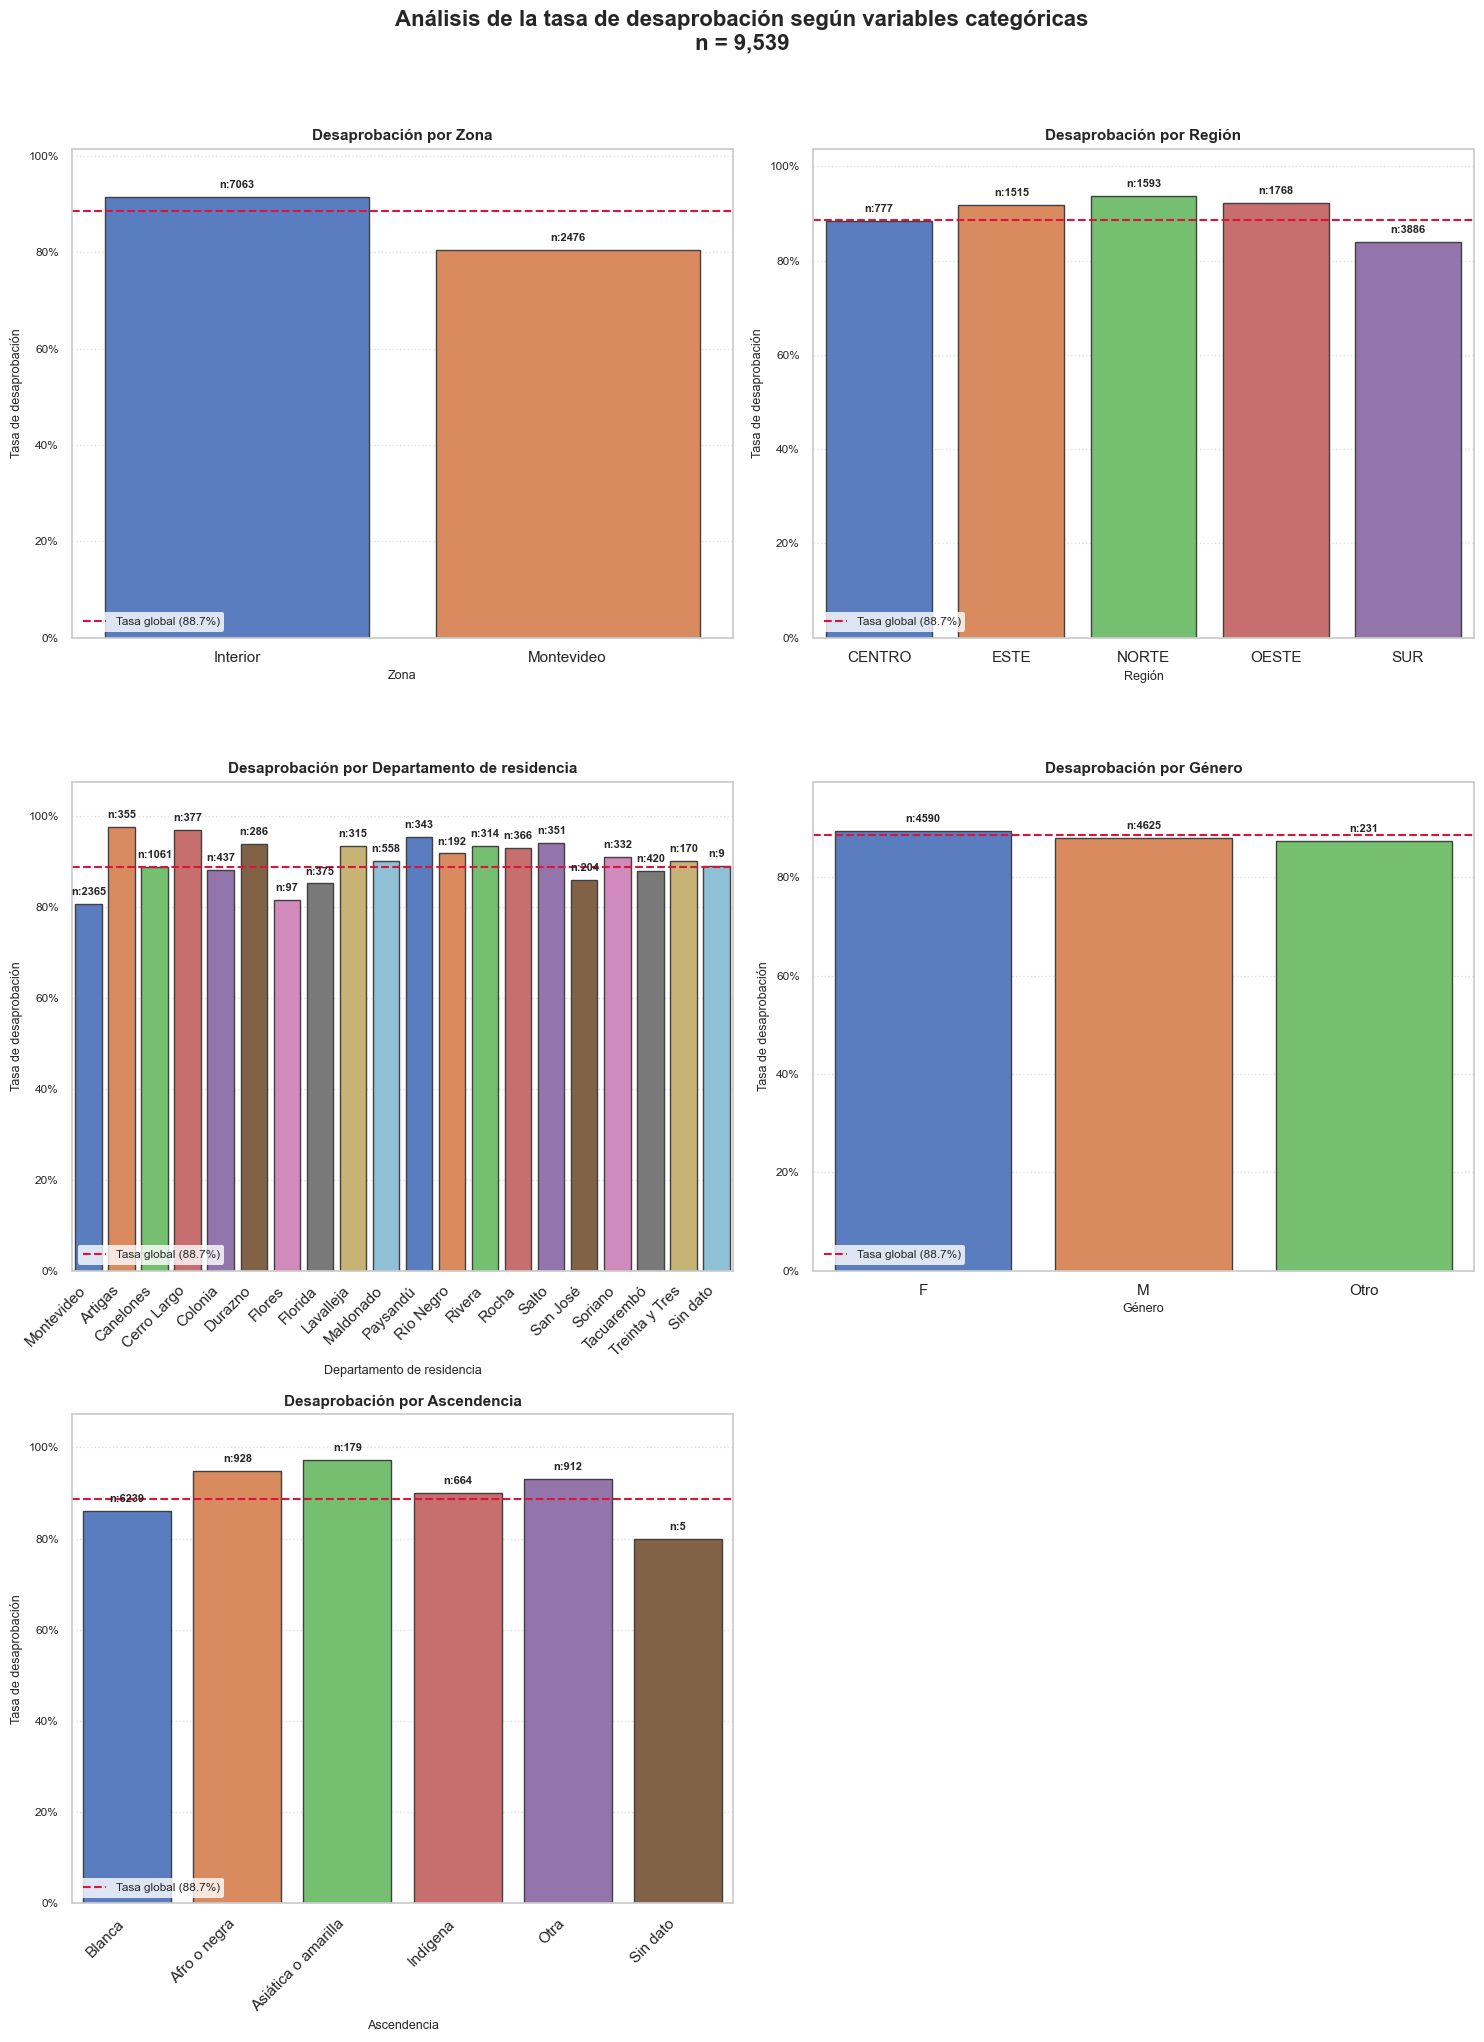

In [6]:
# ==============================
# Variables a graficar
# ==============================
variables_a_graficar = [
    'zona',
    'region',
    'departamento_residencia',
    'alumno_genero',
    'ascendencia'
]

# ==============================
# Diccionarios de etiquetas
# ==============================

mapa_ascendencia = {
    1: "Blanca",
    2: "Afro o negra",
    3: "Asiática o amarilla",
    4: "Indígena",
    5: "Otra"
}

mapa_departamentos = {
    1: "Montevideo",
    2: "Artigas",
    3: "Canelones",
    4: "Cerro Largo",
    5: "Colonia",
    6: "Durazno",
    7: "Flores",
    8: "Florida",
    9: "Lavalleja",
    10: "Maldonado",
    11: "Paysandú",
    12: "Río Negro",
    13: "Rivera",
    14: "Rocha",
    15: "Salto",
    16: "San José",
    17: "Soriano",
    18: "Tacuarembó",
    19: "Treinta y Tres"
}

# Títulos más amigables (opcional)
titulos = {
    'zona': 'Zona',
    'region': 'Región',
    'departamento_residencia': 'Departamento de residencia',
    'alumno_genero': 'Género',
    'ascendencia': 'Ascendencia'
}

# ==============================
# Tasa global
# ==============================

tasa_base = df_final_modelo['target'].mean()

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(15, 20))
axes_flat = axes.flatten()

# ==============================
# Bucle de gráficos
# ==============================

for i, var in enumerate(variables_a_graficar):

    ax = axes_flat[i]
    ax.grid(False)

    data_grafico = (
        df_final_modelo
        .groupby(var)['target']
        .agg(
            tasa='mean',
            n='size'
        )
        .reset_index()
    )

    # Reemplazar etiquetas únicamente para el gráfico
    if var == 'ascendencia':
        data_grafico[var] = data_grafico[var].map(mapa_ascendencia)

    elif var == 'departamento_residencia':
        data_grafico[var] = data_grafico[var].map(mapa_departamentos)

    # Rellenar posibles NaNs (floats) con un texto y asegurar que todo sea string
    data_grafico[var] = data_grafico[var].fillna('Sin dato').astype(str)
    
    orden_categorias = data_grafico[var].tolist()

    sns.barplot(
        x=var,
        y='tasa',
        data=data_grafico,
        order=orden_categorias,
        hue=var,
        hue_order=orden_categorias,
        palette='muted',
        legend=False,
        edgecolor='#404040',
        ax=ax
    )

    # Línea de tasa global
    linea_base = ax.axhline(
        y=tasa_base,
        color='crimson',
        linestyle='--',
        linewidth=1.5
    )

    ax.legend(
        [linea_base],
        [f'Tasa global ({tasa_base:.1%})'],
        loc='lower left',
        fontsize=8.5,
        frameon=True,
        facecolor='white',
        edgecolor='none'
    )

    ax.set_title(
        f'Desaprobación por {titulos.get(var,var)}',
        fontsize=11,
        fontweight='bold'
    )

    ax.set_xlabel(titulos.get(var,var), fontsize=9)
    ax.set_ylabel('Tasa de desaprobación', fontsize=9)

    max_val = data_grafico['tasa'].max()
    ax.set_ylim(0, max(max_val + 0.10, tasa_base + 0.05))

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.tick_params(axis='y', labelsize=8.5)
    ax.grid(axis='y', linestyle=':', alpha=0.6)

    # Rotar etiquetas si son largas
    if var in ['departamento_residencia', 'ascendencia']:
        ax.tick_params(axis='x', rotation=45)
        for tick in ax.get_xticklabels():
            tick.set_horizontalalignment('right')

    # Etiquetas con tamaño muestral
    for j, p in enumerate(ax.patches):

        if j >= len(data_grafico):
            break

        height = p.get_height()

        ax.annotate(
            f"n:{int(data_grafico.iloc[j]['n'])}",
            (p.get_x() + p.get_width()/2, height),
            ha='center',
            va='bottom',
            xytext=(0,5),
            textcoords='offset points',
            fontsize=8,
            fontweight='bold'
        )

# Ocultar ejes sobrantes
for j in range(len(variables_a_graficar), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(
    f'Análisis de la tasa de desaprobación según variables categóricas\nn = {len(df_final_modelo):,}',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

A partir de los gráficos, se observa que la tasa global de desaprobación en la prueba de Matemática es elevada (88,7%), aunque existen diferencias entre los distintos grupos analizados.

- Zona de residencia: los estudiantes del Interior presentan una tasa de desaprobación superior a la media y mayor que la observada en Montevideo, lo que sugiere una leve brecha territorial en el desempeño.

- Región: se aprecian diferencias moderadas entre regiones. Norte, Este y Oeste exhiben las tasas de desaprobación más altas, mientras que la región Sur presenta la menor proporción de estudiantes desaprobados, ubicándose por debajo de la tasa global.

- Departamento de residencia: existe heterogeneidad entre departamentos. Algunos, como Artigas, muestran tasas de desaprobación cercanas al 97%, mientras que Montevideo y Durazno presentan valores relativamente menores. Sin embargo, en varios departamentos el tamaño muestral es reducido, por lo que esas diferencias deben interpretarse con cautela.

- Género: las diferencias son prácticamente inexistentes. Mujeres y varones presentan tasas de desaprobación muy similares, cercanas a la media, mientras que la categoría "Otro" se ubica levemente por debajo, aunque con un número muy pequeño de casos (n=231).

- Ascendencia: se observan algunas diferencias. Los estudiantes que se identifican con ascendencia asiática o amarilla presentan la mayor tasa de desaprobación, seguidos por quienes reportan ascendencia afro o negra y otra. En contraste, quienes declaran ascendencia blanca muestran la menor tasa de desaprobación del grupo, situándose por debajo de la media global.

### 2.3) Boxplots numéricos

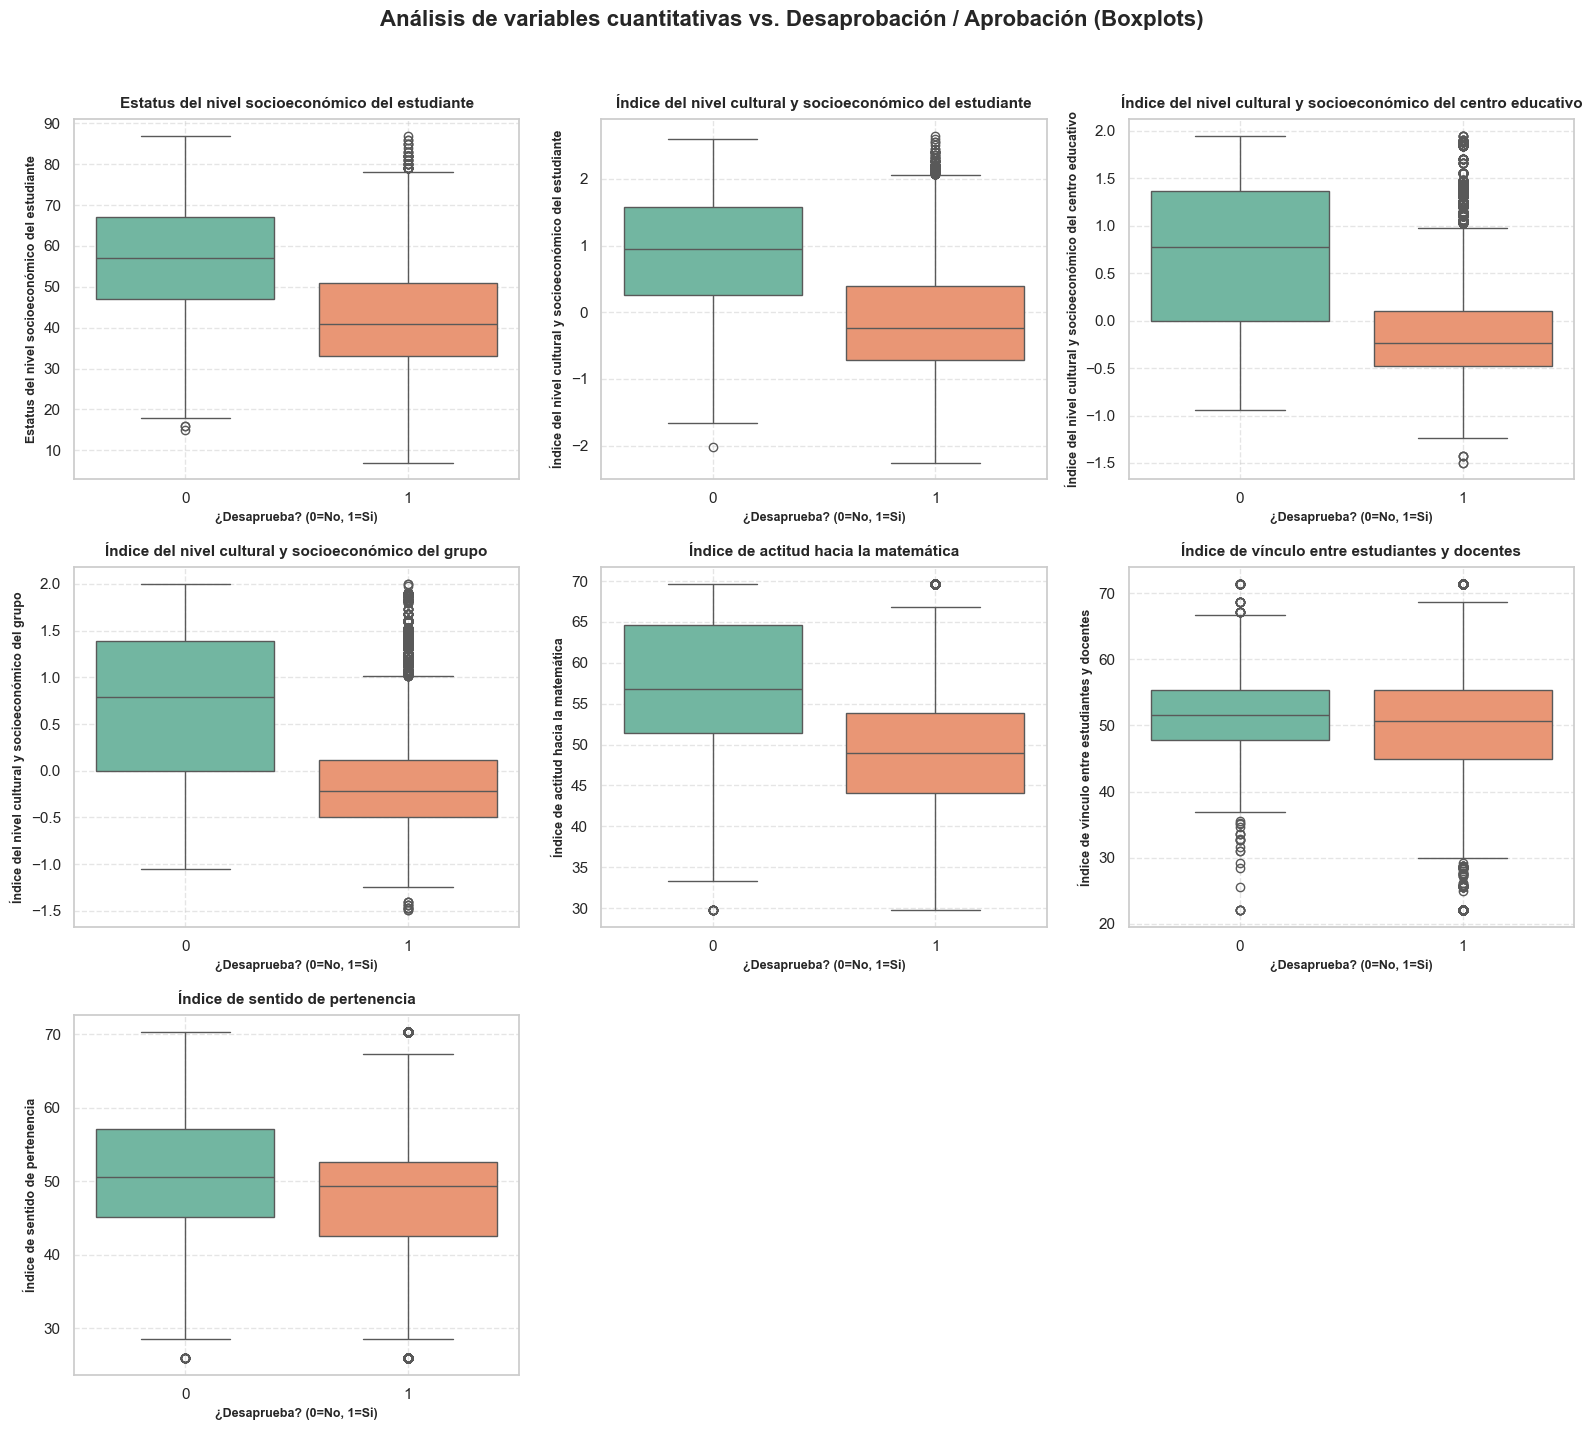

In [ ]:
# Realizar análisis de variables numéricas (Boxplots)

# Definimos las variables numéricas a analizar (Son 7 variables en total)
variables_boxplot = [
    'idx_inse_alumno',
    'idx_esec_alumno',
    'idx_esec_centro',
    'idx_esec_grupo',
    'idx_actitud_matematica',
    'idx_vinculo_estudiantes_docentes',
    'idx_sentido_pertenencia'
]

# Configuramos el estilo estético de Seaborn
sns.set_theme(style="whitegrid")

# SOLUCIÓN: Cambiamos a 3 filas x 3 columnas para que entren las 7 variables
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 14))

# Aplanamos la matriz para iterar linealmente
axes_flat = axes.flat

# Mapeamos títulos
titulos = {
    'idx_inse_alumno': 'Estatus del nivel socioeconómico del estudiante',
    'idx_esec_alumno': 'Índice del nivel cultural y socioeconómico del estudiante',
    'idx_esec_centro': 'Índice del nivel cultural y socioeconómico del centro educativo',
    'idx_esec_grupo': 'Índice del nivel cultural y socioeconómico del grupo',
    'idx_actitud_matematica': 'Índice de actitud hacia la matemática',
    'idx_vinculo_estudiantes_docentes': 'Índice de vínculo entre estudiantes y docentes',
    'idx_sentido_pertenencia': 'Índice de sentido de pertenencia'
}

# Iteramos para construir cada Boxplot
for i, var in enumerate(variables_boxplot):
    ax = axes_flat[i]

    sns.boxplot(
        x='target', # Mejor pasar el string si ya especificamos el data=
        y=var,
        data=df_final_modelo,
        ax=ax,
        palette="Set2",
        hue='target',
        legend=False
    )

    # Adaptamos títulos y etiquetas
    ax.set_title(
        f"{titulos.get(var, var)}",
        fontsize=11,
        fontweight='bold',
        pad=8
    )
    ax.set_xlabel("¿Insatisfactorio? (0=No, 1=Si)", fontsize=9, fontweight='bold')
    ax.set_ylabel(titulos.get(var, var), fontsize=9, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)

# Apagamos cuadrantes vacíos (los espacios 8 y 9)
for j in range(len(variables_boxplot), len(axes_flat)):
    axes_flat[j].axis('off')

# Generamos título general, ajustamos layout y mostramos
plt.suptitle("Análisis de variables cuantitativas vs. Insatisfactorio / Satisfactorio (Boxplots)", y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

A partir de los boxplots se observan diferencias claras entre los estudiantes que aprueban (0) y quienes desaprueban (1) la prueba de Matemática para algunos de los índices analizados.

- Estatus del nivel socioeconómico del estudiante: los estudiantes que aprueban presentan, en general, un nivel socioeconómico más alto. La mediana del índice es considerablemente superior en el grupo que aprueba, mientras que quienes desaprueban se concentran en valores más bajos. Esto sugiere una asociación negativa entre el nivel socioeconómico y la probabilidad de desaprobación.

- Índice del nivel cultural y socioeconómico del estudiante: se observa un patrón similar al anterior. Los estudiantes que aprueban presentan valores positivos y una mediana claramente superior, mientras que quienes desaprueban se concentran en valores inferiores. La diferencia entre ambos grupos es marcada, lo que indica que este índice podría ser un importante factor asociado al desempeño en Matemática.

- Índice de actitud hacia la matemática: los estudiantes que aprueban muestran una actitud más favorable hacia la asignatura, reflejada en una mediana sensiblemente mayor. Aunque existe cierto solapamiento entre ambos grupos, la distribución evidencia que una actitud más positiva hacia la Matemática se asocia con una menor probabilidad de desaprobación.

- Índice de vínculo entre estudiantes y docentes: las distribuciones de ambos grupos son muy similares, con medianas prácticamente iguales y una fuerte superposición de los rangos intercuartílicos. Esto sugiere que, de manera aislada, este indicador presenta una capacidad limitada para diferenciar entre estudiantes que aprueban y desaprueban.

- Índice de sentido de pertenencia: también se observan diferencias reducidas entre ambos grupos. Los estudiantes que aprueban presentan una mediana ligeramente superior, aunque la superposición entre las distribuciones es considerable, por lo que el sentido de pertenencia parece tener una asociación más débil con el resultado de la prueba.

### 2.4) Barplots numéricos

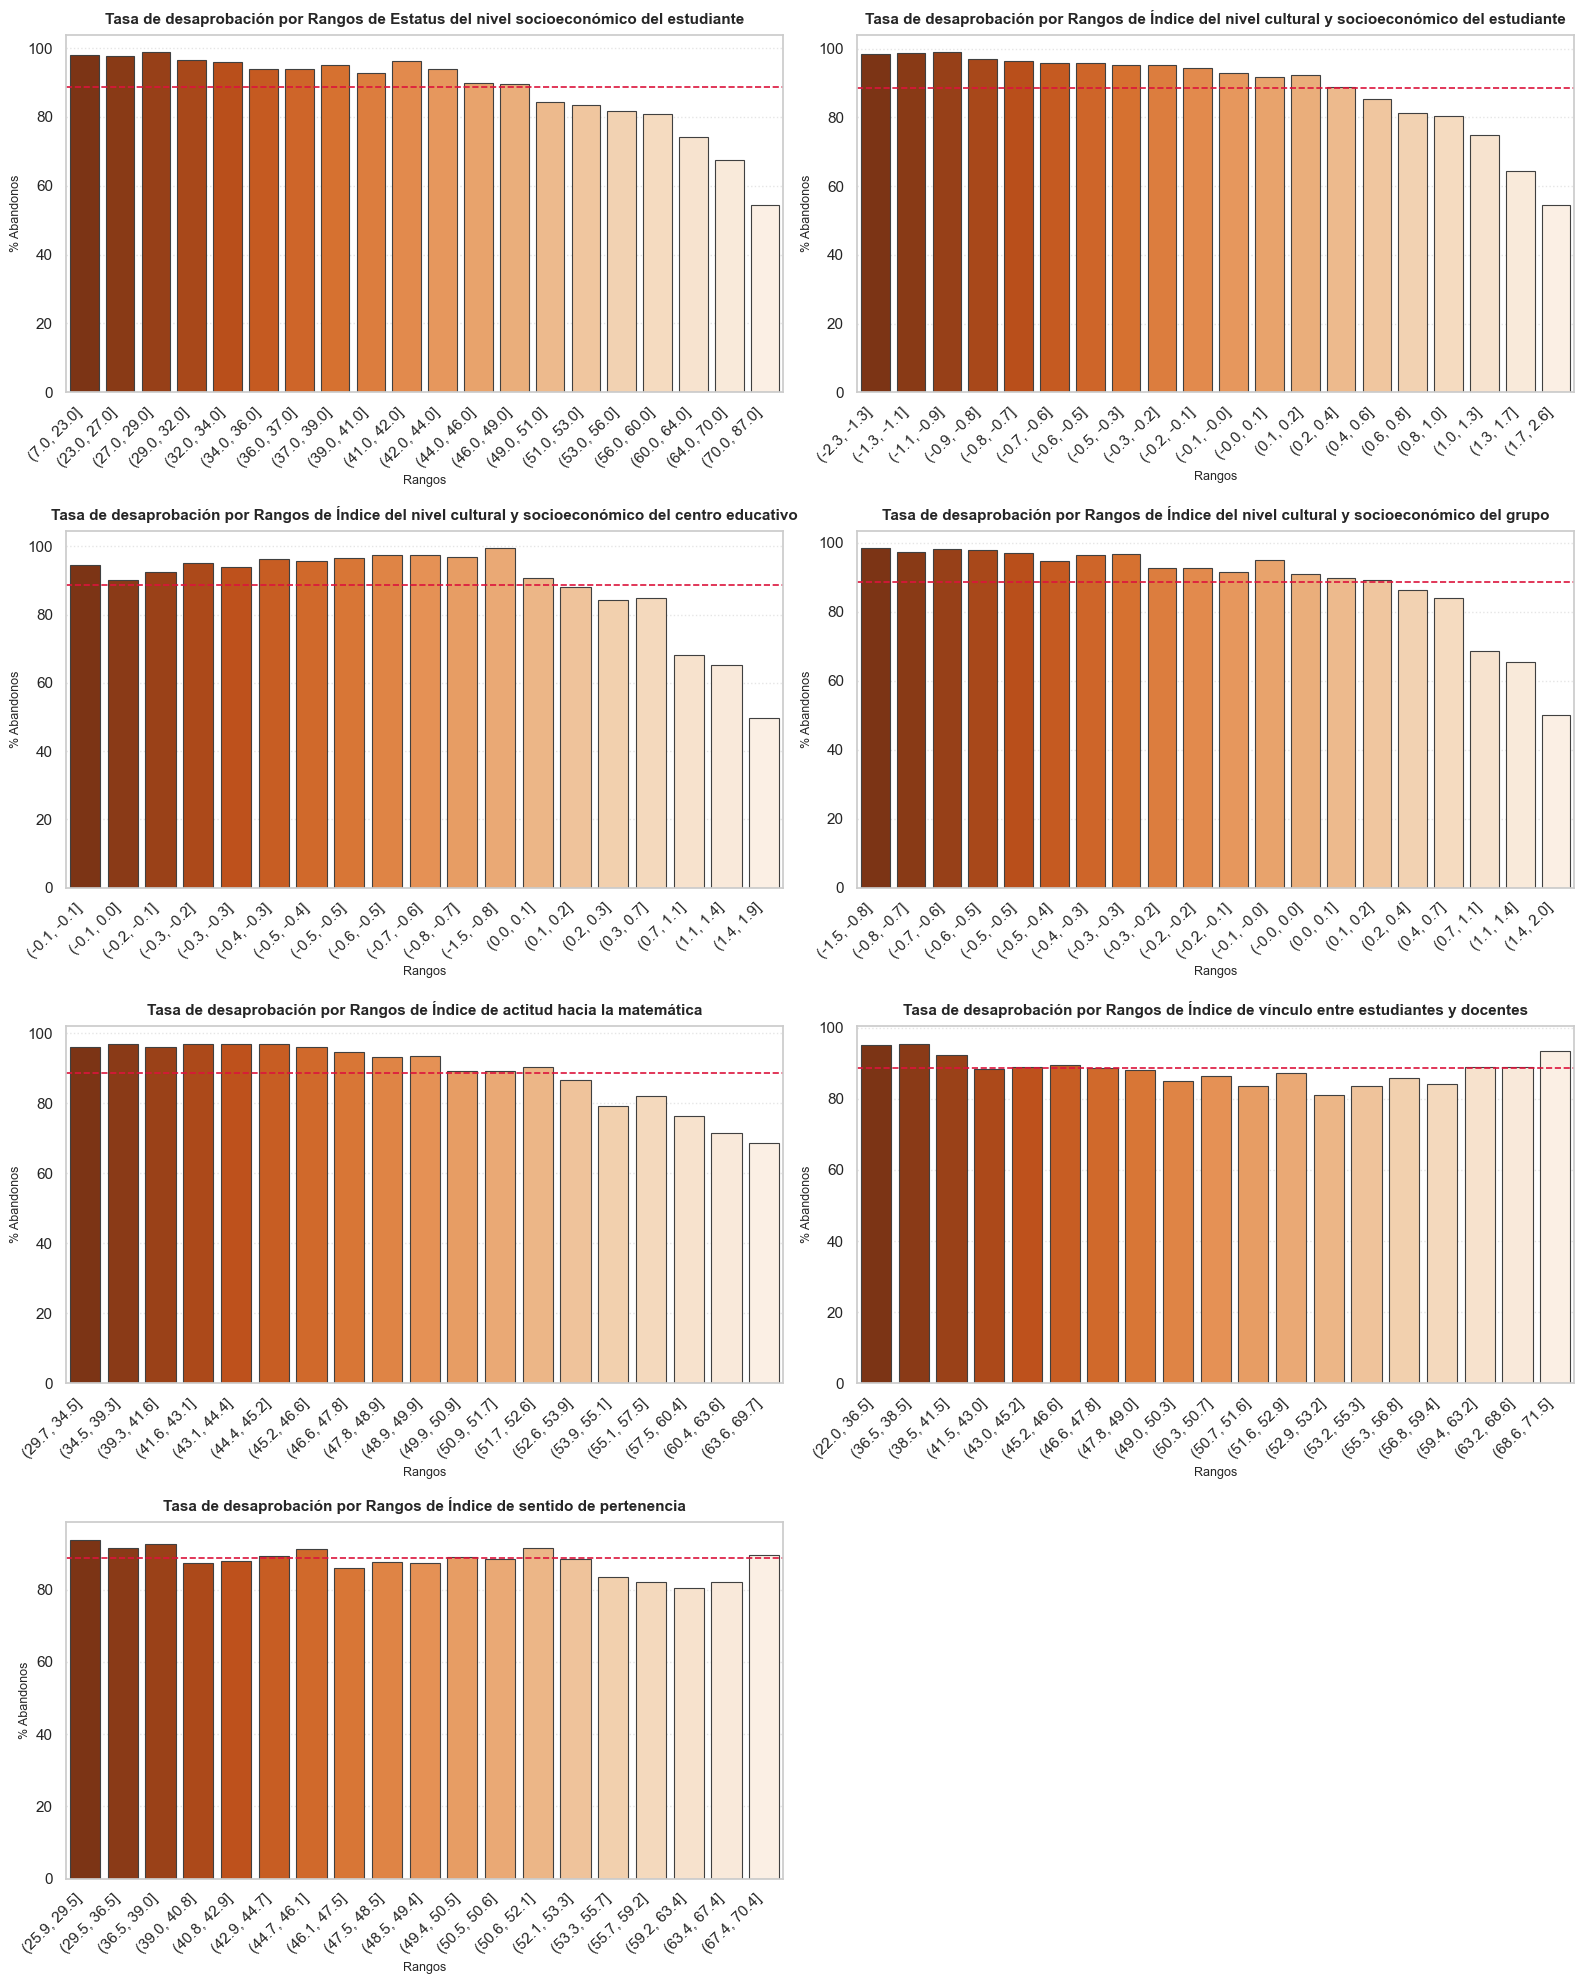

In [ ]:
# Barplots de tasa de desaprobación por rangos de variables numéricas.

# Hacemos lo mismo pero para las variables numericas, pero a estas las tendremos que dividir en rangos para los graficos de barras. 

n_cols = 2
# Calculamos las filas necesarias de forma dinámica
n_rows = math.ceil(len(variables_boxplot) / n_cols) 

# Creamos la copia de trabajo y pasamos el target a porcentaje directo (0 a 100%)
df_plot = df_final_modelo.copy()
df_plot['Desaprueba_porcentaje'] = df_plot['target'].map({1: 100, 0: 0})

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))

# Aplanamos el array de ejes para poder iterar en un solo bucle limpio (aplasta una matriz 2D en 1D)
axes = axes.flatten()

# ==================================================================================================
# BUCLE EN MATRIZ DE SUBPLOTS
# ==================================================================================================
for i, var in enumerate(variables_boxplot):
    ax = axes[i]
    col_intervalo = f'{var}_Rango'
    
    # 1. Creamos los rangos con qcut
    intervalos = pd.qcut(df_plot[var], q=20, duplicates='drop')
    
    # 2. Forzamos estrictamente el formato a 1 decimal (ej: "(25.8, 29.5]")
    df_plot[col_intervalo] = intervalos.apply(
        lambda x: f"({x.left:.1f}, {x.right:.1f}]" if pd.notna(x) else x
    )

    data_tasa_num = (
        df_plot.groupby(col_intervalo, observed=True)['Desaprueba_porcentaje']
        .mean()
        # sort_index() funciona mal si los rangos son texto y no categorías, 
        # pero al venir de qcut, el groupby ya respeta el orden original de los intervalos
        .reset_index()
    )

    # Ya no necesitamos hacer el .astype(str) porque el lambda de arriba ya los convirtió a texto
    
    # Dibujamos el barplot en el eje correspondiente
    sns.barplot(
        x=col_intervalo, 
        y='Desaprueba_porcentaje', 
        data=data_tasa_num, 
        palette='Oranges_r',
        hue=col_intervalo,
        legend=False,
        dodge=False,
        ax=ax,
        edgecolor='#404040', 
        linewidth=0.8
    )

    tasa_base = df_plot['Desaprueba_porcentaje'].mean()  
    
    # Añadimos la línea roja con la tasa base del modelo
    ax.axhline(
        y=tasa_base, 
        color='crimson', 
        linestyle='--', 
        linewidth=1.2, 
        label=f'Base Global ({tasa_base:.2f}%)' if i == 0 else ""
    )

    ax.set_title(f"Tasa de Insatisfactorio por Rangos de {titulos.get(var, var)}", fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Rangos', fontsize=9) 
    ax.set_ylabel('% Insatisfactorio', fontsize=9)
    ax.set_ylim(0, max(data_tasa_num['Desaprueba_porcentaje'].max() + 5, 25))
    ax.grid(axis='y', linestyle=':', alpha=0.5)

    ax.tick_params(axis='x', rotation=45)
    for tick in ax.get_xticklabels():
        tick.set_horizontalalignment('right')

# Eliminamos los subplots sobrantes si el número de variables es impar
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 2.5) Correlaciones lineales

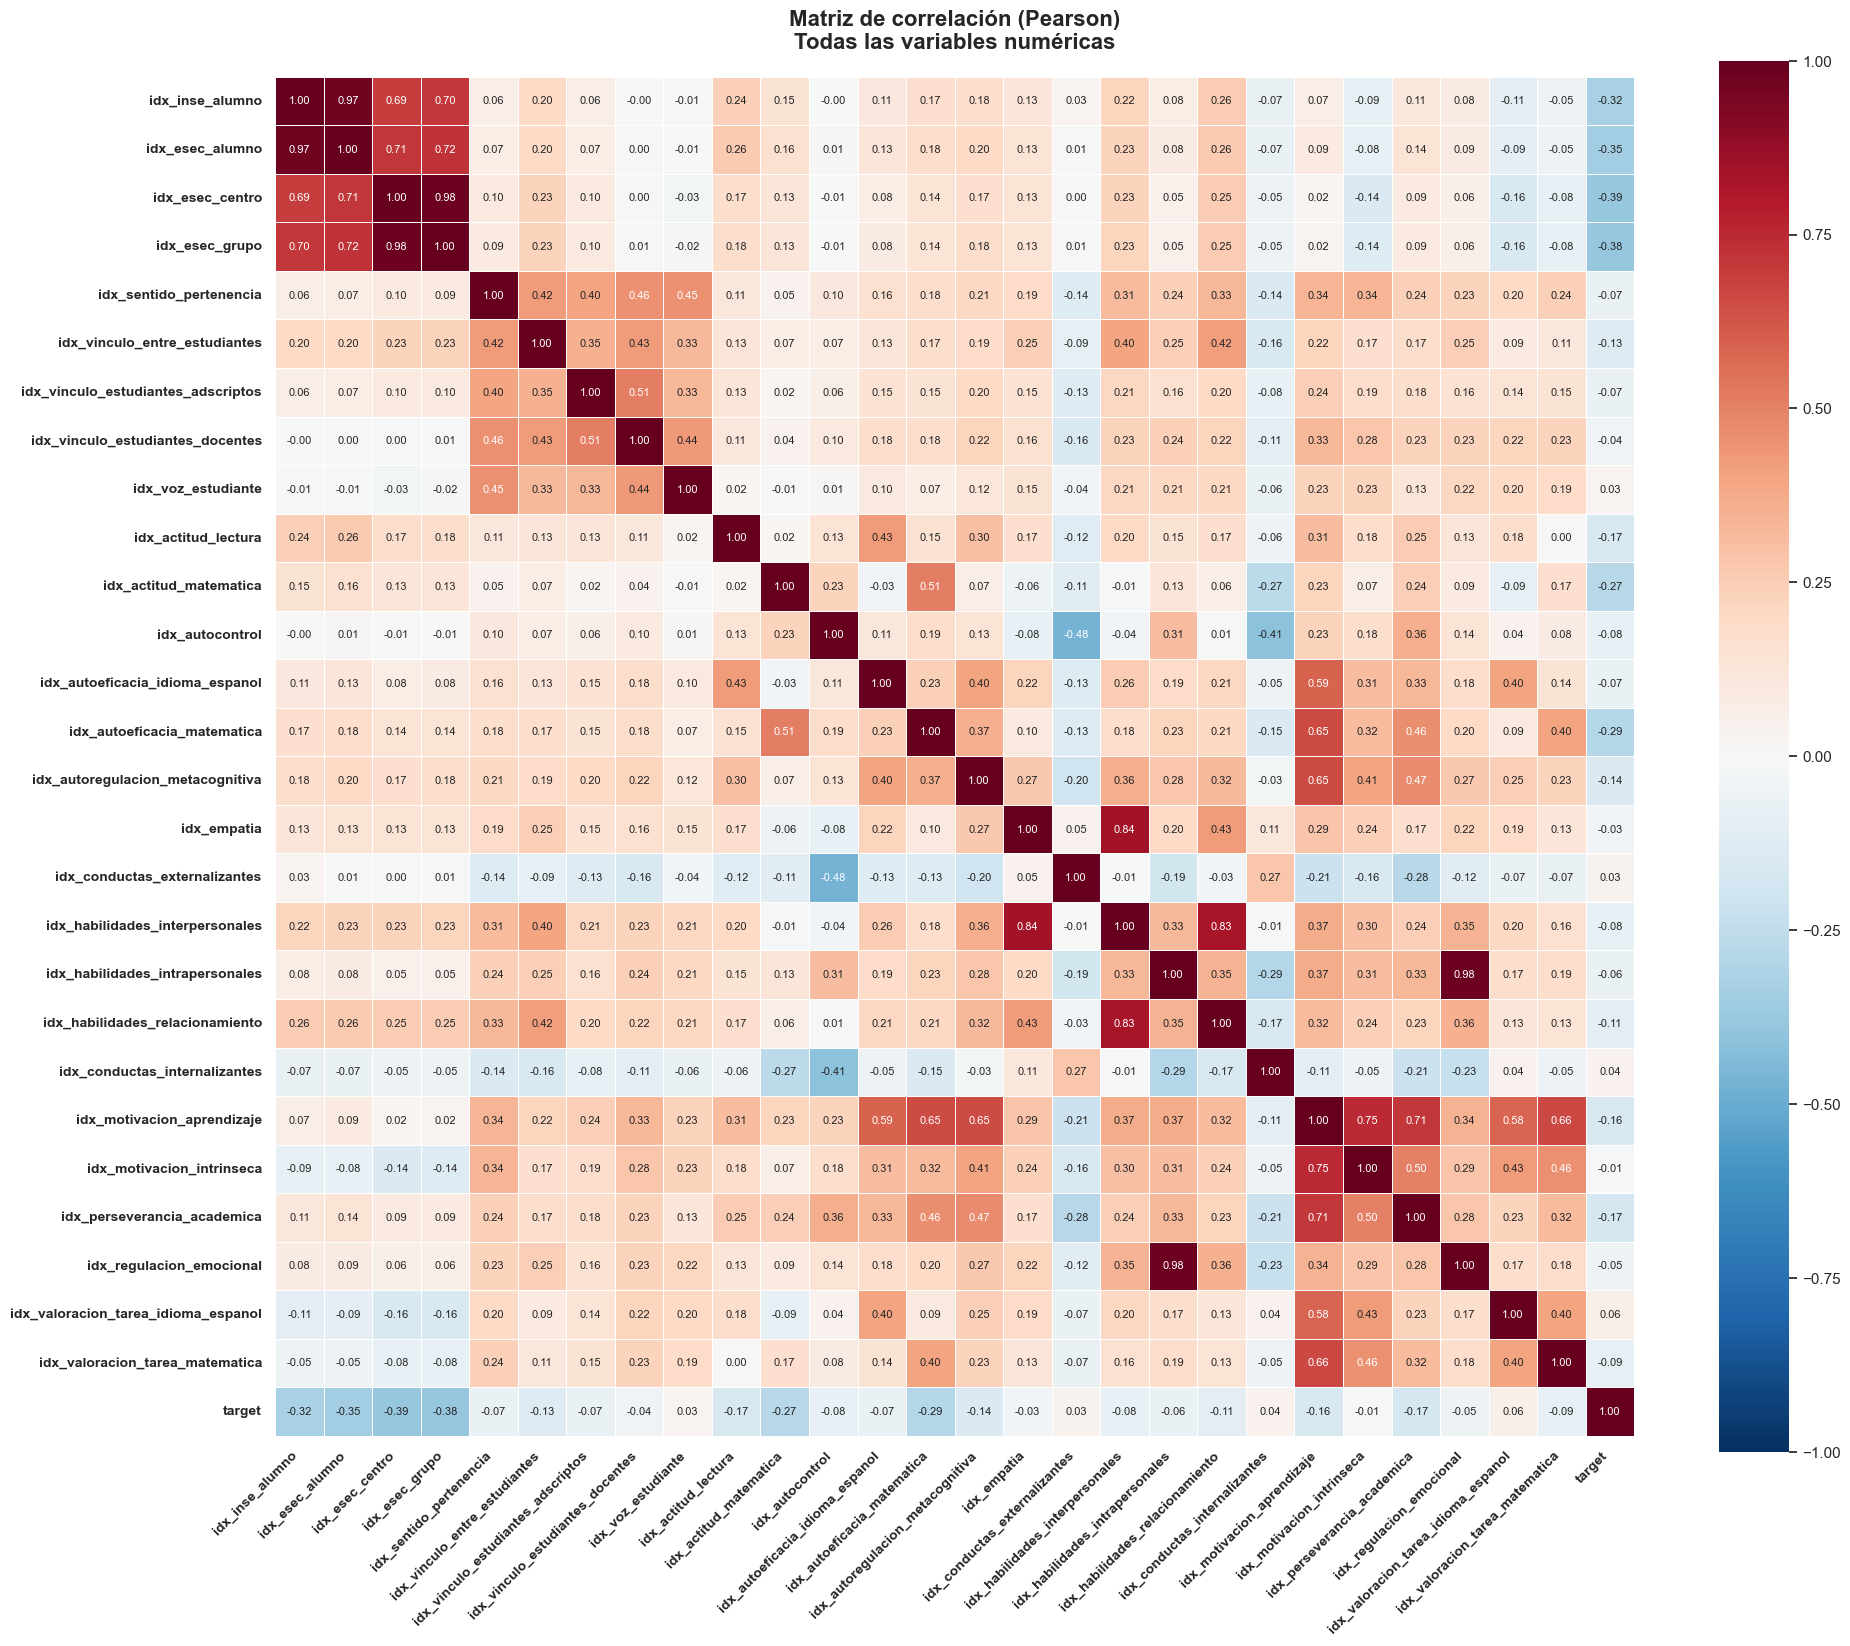

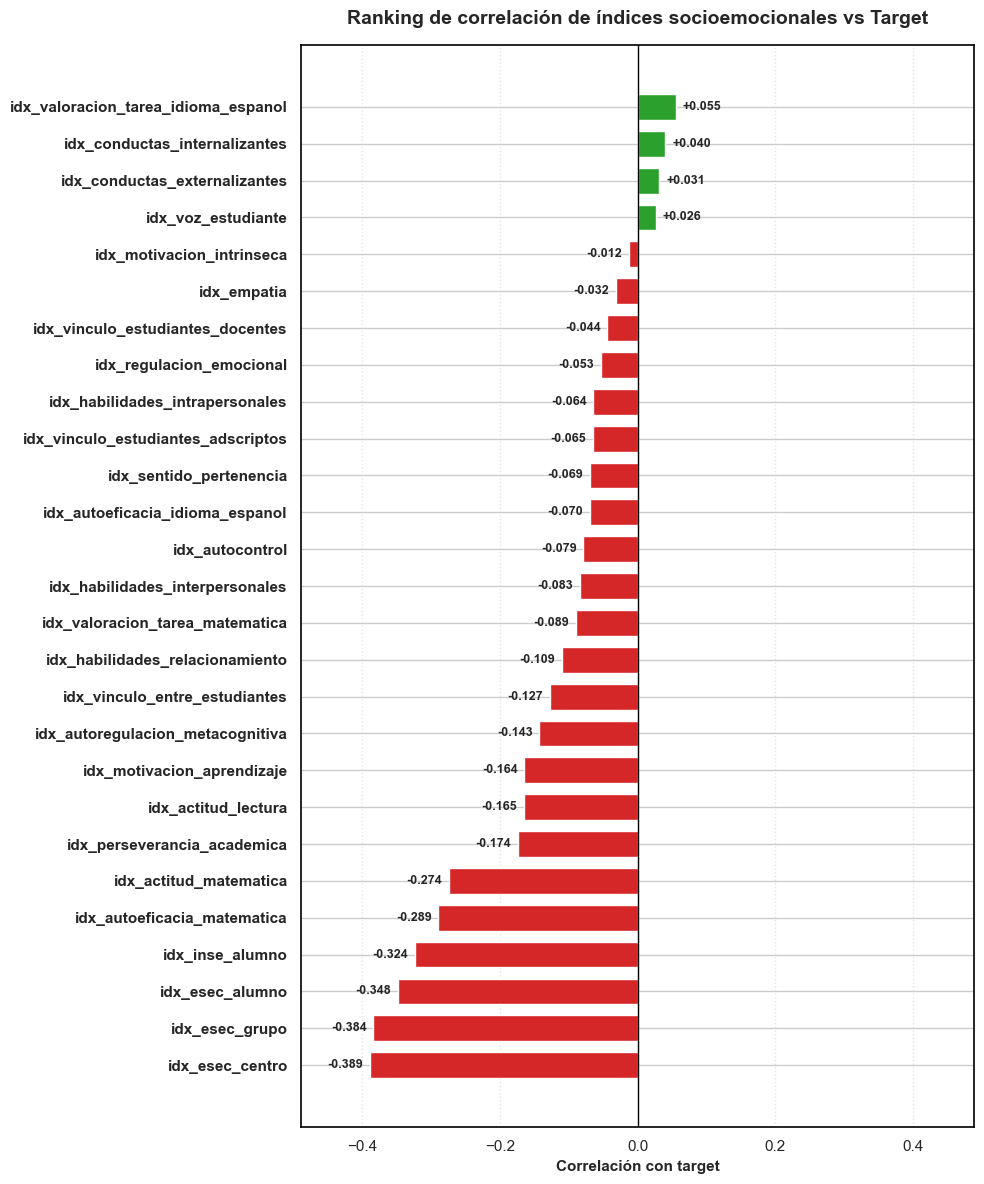

In [9]:
#  Generar matriz de correlación (todas las variables numéricas + target)

variables_corr = [
    # --- Índices de Estatus Económico y Social ---
    'idx_inse_alumno',
    'idx_esec_alumno',
    'idx_esec_centro',
    'idx_esec_grupo',
    
    # --- Índices de Contexto y Actitudes ---
    'idx_sentido_pertenencia',
    'idx_vinculo_entre_estudiantes',
    'idx_vinculo_estudiantes_adscriptos',
    'idx_vinculo_estudiantes_docentes',
    'idx_voz_estudiante',
    'idx_actitud_lectura',
    'idx_actitud_matematica',
    
    # --- Índices de Habilidades Socioemocionales y Cognitivas ---
    'idx_autocontrol',
    'idx_autoeficacia_idioma_espanol',
    'idx_autoeficacia_matematica',
    'idx_autoregulacion_metacognitiva',
    'idx_empatia',
    'idx_conductas_externalizantes',
    'idx_habilidades_interpersonales',
    'idx_habilidades_intrapersonales',
    'idx_habilidades_relacionamiento',
    'idx_conductas_internalizantes', 
    'idx_motivacion_aprendizaje',
    'idx_motivacion_intrinseca',
    'idx_perseverancia_academica',
    'idx_regulacion_emocional',
    'idx_valoracion_tarea_idioma_espanol',
    'idx_valoracion_tarea_matematica'
]

# Seleccionar únicamente las variables de interés
df_eda_corr = df_final_modelo[variables_corr + ['target']].copy()

# Matriz de correlación
corr_eda = df_eda_corr.corr(numeric_only=True)

# Reordenar para dejar el target al final
cols_ordenadas = [c for c in corr_eda.columns if c != 'target'] + ['target']
corr_eda = corr_eda.loc[cols_ordenadas, cols_ordenadas]


# =========================================================
# HEATMAP DE CORRELACIÓN
# =========================================================
# Aumentamos considerablemente el tamaño de la figura (20x18)
plt.figure(figsize=(20, 18))

sns.heatmap(
    corr_eda,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.85},
    annot_kws={"size": 8} # Reducimos un poco el tamaño de la fuente de los números
)

plt.xticks(rotation=45, ha='right', fontsize=10, fontweight='bold')
plt.yticks(fontsize=10, fontweight='bold')
plt.title(
    'Matriz de correlación (Pearson)\nTodas las variables numéricas',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.show()


# =========================================================
# RANKING TORNADO (CORRELACIÓN CON EL TARGET)
# =========================================================

corr_target = corr_eda['target'].drop('target')

ranking_pos = corr_target[corr_target >= 0].sort_values(ascending=False)
ranking_neg = corr_target[corr_target < 0].sort_values(ascending=False)

ranking = pd.concat([ranking_pos, ranking_neg])

# Aumentamos la altura de la figura para acomodar 27 barras sin superponerse
fig, ax = plt.subplots(figsize=(10, 12))

colores = ['#2ca02c' if v >= 0 else '#d62728' for v in ranking]

ax.barh(ranking.index, ranking.values, color=colores, height=0.7)
ax.axvline(0, color='black', linewidth=1)

ax.invert_yaxis()
ax.set_xlabel('Correlación con target', fontweight='bold', fontsize=11)
ax.set_title(
    'Ranking de correlación de índices socioemocionales vs Target',
    fontsize=14,
    fontweight='bold',
    pad=15
)

# CORRECCIÓN 1: Definimos los ticks primero y luego las etiquetas para evitar el UserWarning
ax.set_yticks(range(len(ranking)))
ax.set_yticklabels(ranking.index, fontweight='bold')

for i, v in enumerate(ranking.values):
    ax.text(
        v + (0.01 if v >= 0 else -0.01),
        i,
        f'{v:+.3f}',
        va='center',
        ha='left' if v >= 0 else 'right',
        fontsize=9,
        fontweight='bold'  # CORRECCIÓN 2: Cambiamos 'semibold' por 'bold' para evitar el warning de fuente
    )

lim = max(abs(ranking.min()), abs(ranking.max())) + 0.1
ax.set_xlim(-lim, lim)
ax.grid(axis='x', linestyle=':', alpha=0.5)

# Borde exterior grueso
for spine in ax.spines.values():
    spine.set_linewidth(1.2)
    spine.set_color('black')

plt.tight_layout()
plt.show()

Análisis de correlaciones con la tasa de desaprobación (target)

* Los factores socioeconómicos y educativos (idx_inse_alumno e idx_esec_alumno) son los que más se asocian (aunque de forma moderada) con la desaprobación: a mejores índices, menor tasa de desaprobación.

* La actitud hacia matemáticas tiene cierta influencia, pero es más débil que los factores estructurales.

* El vínculo con docentes y el sentido de pertenencia tienen una correlación casi nula con la desaprobación, lo que sugiere que, en este contexto, no son factores determinantes para explicar el rendimiento en términos de aprobación/desaprobación.

* No hay correlaciones fuertes (todas están por debajo de 0.4 en valor absoluto), lo que indica que la desaprobación es un fenómeno multifactorial y que estas variables explican solo una parte de su variabilidad.

Durante el análisis exploratorio (EDA), se identificó la presencia de valores atípicos (e.g., códigos 98 y 99) en variables sociodemográficas como la Ascendencia. Dado que el diccionario de datos oficial del INEEd solo categoriza respuestas del 1 al 5, se infirió que estos códigos corresponden a marcas de sistema para 'No sabe/No contesta'. En consecuencia, fueron transformados a nulos (NaN) para permitir un manejo correcto en el Pipeline de imputación y no distorsionar la evaluación de equidad algorítmica.  

Para el INEEd cada nivel describe qué es capaz de hacer el estudiante en términos de complejidad cognitiva, basándose en los programas oficiales de ANEP:
- B1 y Nivel 1: El estudiante solo puede resolver tareas matemáticas muy elementales, rutinarias y con información explícita.
- Nivel 2: Logra resolver problemas simples de un solo paso o extraer datos directos de tablas y gráficos.
- Nivel 3: Es considerado habitualmente el nivel de transición o el umbral de competencia básica esperada. El estudiante puede resolver problemas que requieren relacionar algunos datos o hacer cálculos secuenciales sencillos.
- Niveles 4 y 5: El estudiante demuestra una consolidación profunda. Es capaz de modelizar matemáticamente situaciones de la vida real, resolver problemas no rutinarios, interpretar conceptos algebraicos y argumentar sus respuestas.

La binarización aplicada responde a una mirada de política pública orientada a la excelencia y consolidación real de los aprendizajes, donde el "rendimiento satisfactorio" no es solo "saber lo mínimo indispensable" (Nivel 3), sino tener la robustez cognitiva (Niveles 4 y 5) necesaria para continuar trayectorias educativas complejas sin rezago.

## 3) Entrenamiento de los modelos

### 3.1) Categorización de variables

In [10]:
# Definición explicita de las columnas categóricas basadas en el diccionario

 # --- Variables Demográficas y Geográficas ---
columnas_categoricas = [
    "zona",
    "region",
    "departamento_residencia",
    "categoria_centro",
    "categoria_grupo",
    "alumno_genero",
    "ascendencia",
    "pais_nacimiento",
    "edad"
]

# Las columnas numéricas serán todas las demás de X
columnas_numericas = [col for col in X.columns if col not in columnas_categoricas]

# Por precaución extra, forzamos a numérico (convierte cualquier problema a NaN para que el imputer trabaje)
X = X.copy()
X[columnas_numericas] = X[columnas_numericas].apply(pd.to_numeric, errors='coerce')

### 3.2) Column transformers 

In [11]:
# Imputación KNN para numéricas y escalado
transformador_num = Pipeline(steps=[
    ("imputer", KNNImputer(n_neighbors=5, weights="distance")),
    ("scaler", StandardScaler()),
])

# Imputación por moda y OneHot para categóricas
transformador_cat = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
])

preprocesador = ColumnTransformer(transformers=[
    ("num", transformador_num, columnas_numericas),
    ("cat", transformador_cat, columnas_categoricas),
])

### 3.3) Definición de modelos y corrida

In [12]:
# Desactivar el enrutamiento estricto para evitar conflictos
sklearn.set_config(enable_metadata_routing=False)

# Dataset desbalanceado: calcular el ratio de clases para ajustar el parámetro scale_pos_weight en XGBoost
ratio_clases = (y == 0).sum() / (y == 1).sum()
scale_pos_weight_val = ratio_clases

# Definir modelos a analizar
modelos = {
    "Regresion_Logistica": LogisticRegression(random_state=42, class_weight="balanced", max_iter=3000, solver="saga"),
    "Random_Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    "XGBoost": XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight_val, eval_metric="logloss")
}

# Definir grillas de hiperparámetros más compactas y enfocadas en inferencia
param_grids = {
    "Regresion_Logistica": {
        "clasificador__C": [0.1, 1.0, 10.0],
        "clasificador__l1_ratio": [0.0, 0.5, 1.0]
    },
    "Random_Forest": {
        'clasificador__n_estimators': [100, 200],
        'clasificador__max_depth': [5, 8, 12], 
        'clasificador__min_samples_split': [20, 50, 100],
        'clasificador__min_samples_leaf': [10, 30, 50] 
    },
    "XGBoost": {
        'clasificador__n_estimators': [100, 200],
        'clasificador__max_depth': [3, 5, 7],         # XGBoost requiere mucha menos profundidad que RF
        'clasificador__learning_rate': [0.05, 0.1],   # Controla qué tan rápido aprende, evita memorización
        'clasificador__subsample': [0.8, 1.0]         # Usa el 80% de los datos por árbol, excelente para evitar sobreajuste
    }
}

cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados_grid = {}

# Entrenar todos los modelos
for nombre_modelo, modelo in modelos.items():
    print(f"\nEntrenando {nombre_modelo}...")
    
    pipeline_completo = Pipeline(steps=[
        ("preprocesamiento", preprocesador),
        ("clasificador", modelo)
    ])
    
    grid_search = GridSearchCV(
        estimator=pipeline_completo,
        param_grid=param_grids[nombre_modelo],
        cv=cv_estrategia,
        scoring="roc_auc",
        n_jobs=7,
        error_score="raise"
    )
    
    # Pasamos los pesos directamente al clasificador
    grid_search.fit(X, y, clasificador__sample_weight=w)
    
    resultados_grid[nombre_modelo] = grid_search


Entrenando Regresion_Logistica...

Entrenando Random_Forest...

Entrenando XGBoost...


### 3.4) Resultados de los modelos

In [13]:
mejor_nombre = None
mejor_score = 0
mejor_grid = None

print("\n--- Comparación de Modelos (ROC-AUC en Validación Cruzada) ---")
for nombre, grid in resultados_grid.items():
    score_cv = grid.best_score_
    mejores_params = grid.best_params_
    
    print(f"\nModelo: {nombre}")
    print(f"Score (ROC-AUC): {score_cv:.4f}")
    print("Hiperparámetros elegidos:")
    
    # Imprimimos cada hiperparámetro de forma clara
    for param, valor in mejores_params.items():
        print(f"  - {param}: {valor}")
        
    print("-" * 50)
    
    if score_cv > mejor_score:
        mejor_score = score_cv
        mejor_nombre = nombre
        mejor_grid = grid


--- Comparación de Modelos (ROC-AUC en Validación Cruzada) ---

Modelo: Regresion_Logistica
Score (ROC-AUC): 0.8814
Hiperparámetros elegidos:
  - clasificador__C: 0.1
  - clasificador__l1_ratio: 0.0
--------------------------------------------------

Modelo: Random_Forest
Score (ROC-AUC): 0.8747
Hiperparámetros elegidos:
  - clasificador__max_depth: 12
  - clasificador__min_samples_leaf: 10
  - clasificador__min_samples_split: 20
  - clasificador__n_estimators: 200
--------------------------------------------------

Modelo: XGBoost
Score (ROC-AUC): 0.8840
Hiperparámetros elegidos:
  - clasificador__learning_rate: 0.1
  - clasificador__max_depth: 3
  - clasificador__n_estimators: 200
  - clasificador__subsample: 0.8
--------------------------------------------------


### 3.5) Cálculo de Feature y Permutation Importance

In [14]:
modelos_comparar = ["Regresion_Logistica", "Random_Forest", "XGBoost"]
importancias_internas = {}
importancias_permutacion = {}

for nombre_modelo in modelos_comparar:
    grid = resultados_grid[nombre_modelo]
    mejor_pipeline = grid.best_estimator_

    prepro = mejor_pipeline.named_steps["preprocesamiento"]
    clasif = mejor_pipeline.named_steps["clasificador"]

    feature_names = prepro.get_feature_names_out()

    if nombre_modelo == "Regresion_Logistica":
        # Magnitud del coeficiente para hacerla comparable con RF
        imp_interna = np.abs(clasif.coef_).ravel()
    else:
        imp_interna = clasif.feature_importances_

    serie_interna = pd.Series(imp_interna, index=feature_names, name=nombre_modelo)
    importancias_internas[nombre_modelo] = serie_interna

    # 1. Transformamos los datos originales para obtener las columnas preprocesadas
    X_trans = prepro.transform(X)
    
    # 2. Calculamos la permutación usando SOLO el clasificador y los datos transformados
    perm = permutation_importance(
        clasif,
        X_trans,
        y,
        scoring="roc_auc",
        n_repeats=15,
        random_state=42,
        n_jobs=-1,
        sample_weight=w,
    )
    serie_perm = pd.Series(perm.importances_mean, index=feature_names, name=nombre_modelo)
    importancias_permutacion[nombre_modelo] = serie_perm

### 3.6) Cálculo de RFECV

In [15]:
# Habilitamos el enrutamiento de metadatos (necesario para pasar sample_weight a RFECV)
sklearn.set_config(enable_metadata_routing=True)

# Modelos a evaluar con RFECV
modelos_rfecv = ["Regresion_Logistica", "Random_Forest", "XGBoost"]

# CV para RFECV
cv_rfecv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

resultados_rfecv = {}
resumen_rfecv = []

for nombre_modelo in modelos_rfecv:
    print(f"\nEjecutando RFECV para: {nombre_modelo}")

    # Tomamos el mejor pipeline de GridSearchCV
    mejor_pipeline = resultados_grid[nombre_modelo].best_estimator_
    prepro = mejor_pipeline.named_steps["preprocesamiento"]
    clasif = mejor_pipeline.named_steps["clasificador"]

    # Transformamos X al espacio de features del modelo
    X_trans = prepro.transform(X)
    feature_names = prepro.get_feature_names_out()

    # Clonamos el clasificador
    clasif_clonado = clone(clasif)
    
    # 2. Le indicamos explícitamente al clasificador que acepte los pesos durante el fit
    if hasattr(clasif_clonado, "set_fit_request"):
        clasif_clonado.set_fit_request(sample_weight=True)

    # 3. Creamos un scorer explícito y le indicamos que acepte pesos muestrales
    auc_scorer = make_scorer(roc_auc_score, response_method=('decision_function', 'predict_proba'))
    auc_scorer.set_score_request(sample_weight=True)

    # RFECV con el clasificador (clonado y configurado)
    rfecv = RFECV(
        estimator=clasif_clonado,
        step=1,
        cv=cv_rfecv,
        scoring=auc_scorer,  # <--- Pasamos nuestro scorer en lugar del string "roc_auc"
        n_jobs=-1,
        min_features_to_select=5,
    )

    # sample_weight ahora viajará correctamente hacia cada fit y cada evaluación
    rfecv.fit(X_trans, y, sample_weight=w)

    # Guardamos resultados
    mask = rfecv.support_
    seleccionadas = pd.Index(feature_names)[mask].tolist()

    resultados_rfecv[nombre_modelo] = {
        "selector": rfecv,
        "n_features": rfecv.n_features_,
        "selected_features": seleccionadas,
        "cv_scores": rfecv.cv_results_["mean_test_score"],
    }

    resumen_rfecv.append({
        "Modelo": nombre_modelo,
        "N_features_seleccionadas": rfecv.n_features_,
        "ROC_AUC_max_cv": float(np.max(rfecv.cv_results_["mean_test_score"])),
    })

    print(f"- Features seleccionadas: {rfecv.n_features_}")
    print(f"- Mejor ROC-AUC CV (RFECV): {np.max(rfecv.cv_results_['mean_test_score']):.4f}")


Ejecutando RFECV para: Regresion_Logistica
- Features seleccionadas: 64
- Mejor ROC-AUC CV (RFECV): 0.8797

Ejecutando RFECV para: Random_Forest
- Features seleccionadas: 65
- Mejor ROC-AUC CV (RFECV): 0.8777

Ejecutando RFECV para: XGBoost
- Features seleccionadas: 57
- Mejor ROC-AUC CV (RFECV): 0.8819


## 4) Gráficas comparativas

### 4.1) Top 10 (Internas, Permutación, RFECV)

TOP VARIABLES SELECCIONADAS POR CADA MODELO (RFECV)


,Regresion_Logistica,Random_Forest,XGBoost
Rank 1,num__idx_esec_alumno,num__idx_actitud_matematica,num__idx_esec_alumno
Rank 2,cat__departamento_residencia_2.0,num__idx_esec_centro,num__idx_esec_grupo
Rank 3,cat__categoria_grupo_UTU-FPB,num__idx_esec_alumno,num__idx_autoeficacia_matematica
Rank 4,num__idx_inse_alumno,num__idx_autoeficacia_matematica,cat__categoria_centro_Secundaria pública
Rank 5,cat__departamento_residencia_16.0,num__idx_esec_grupo,num__idx_actitud_matematica
Rank 6,cat__departamento_residencia_5.0,num__idx_inse_alumno,cat__categoria_centro_UTU
Rank 7,num__idx_autoeficacia_matematica,cat__categoria_grupo_Secundaria privada,num__idx_esec_centro
Rank 8,num__idx_actitud_matematica,num__idx_motivacion_aprendizaje,cat__categoria_grupo_UTU-FPB
Rank 9,num__idx_esec_centro,num__idx_actitud_lectura,num__idx_actitud_lectura
Rank 10,cat__departamento_residencia_19.0,num__idx_perseverancia_academica,cat__categoria_centro_Secundaria privada


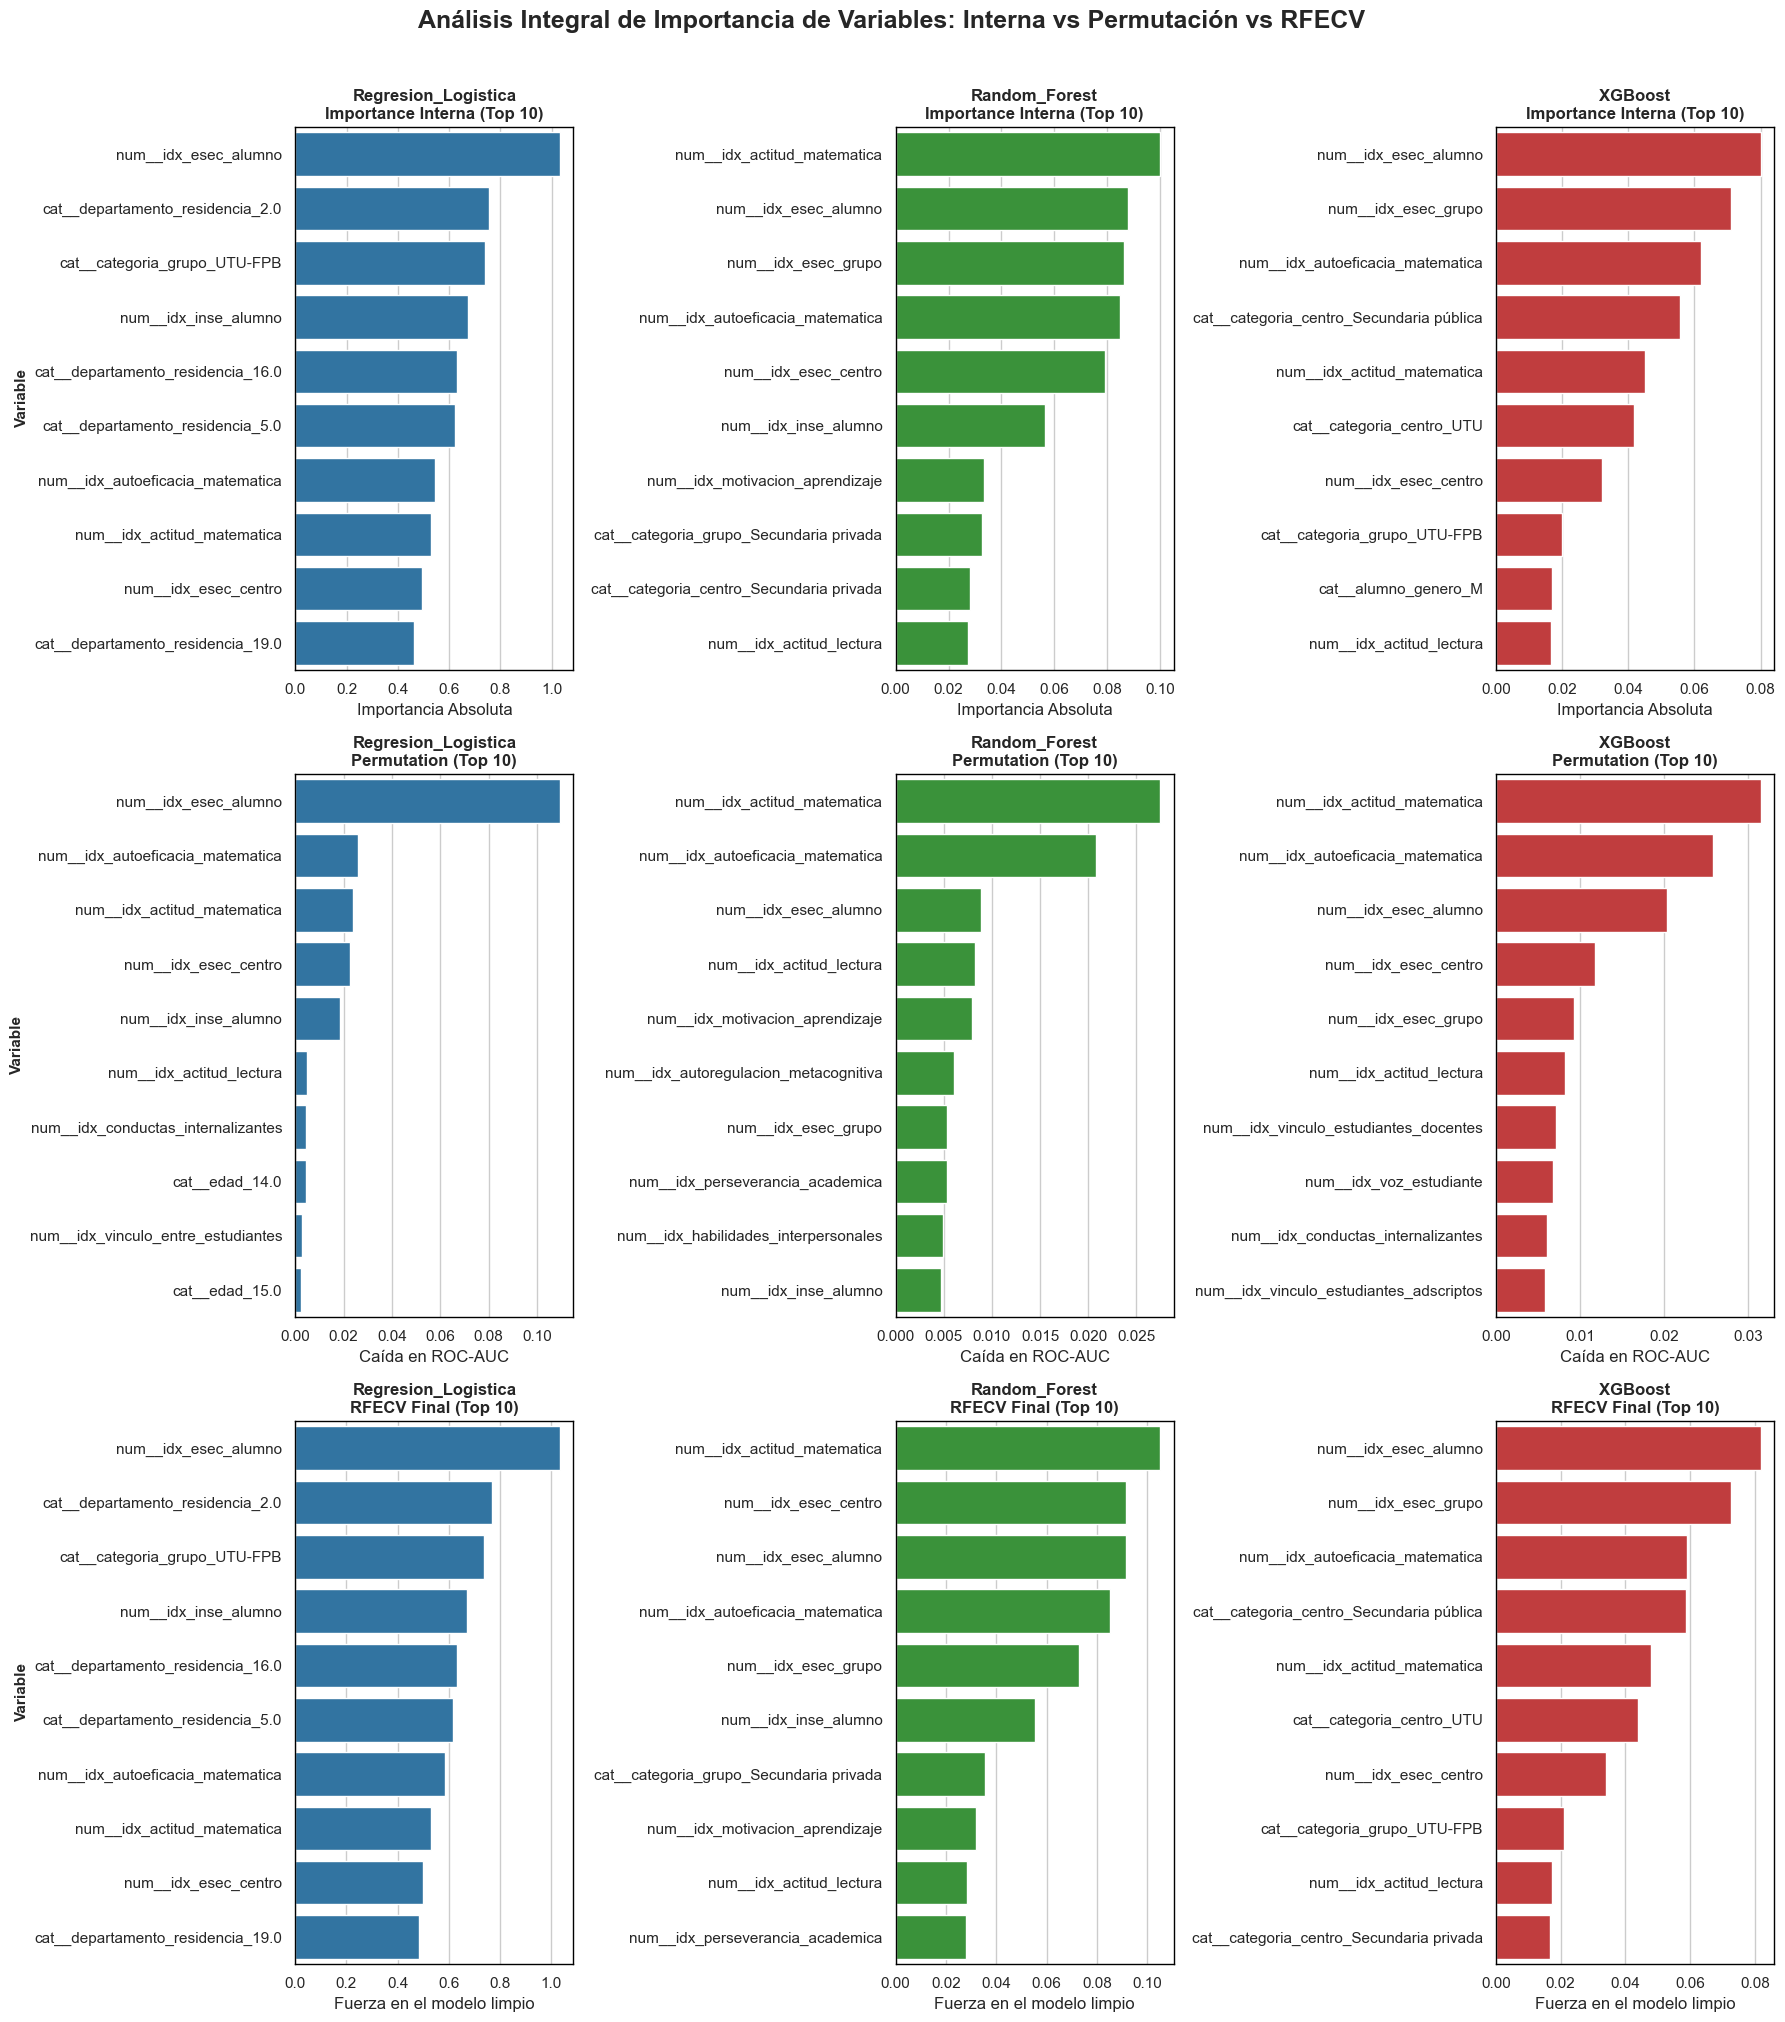

In [16]:


# ---------------------------------------------------------
# 1. PREPARACIÓN DE DATOS
# ---------------------------------------------------------
# Unimos diccionarios de los primeros pasos
df_imp_interna = pd.concat(importancias_internas, axis=1)
df_imp_perm = pd.concat(importancias_permutacion, axis=1)

top20_nombres_dict = {}
top20_series_dict = {}
top_n_standard = 10  # Cantidad a mostrar en Interna y Permutación
top_n_rfecv = 10     # Cantidad a mostrar en RFECV

# Extraemos las importancias finales de RFECV
for nombre_modelo in modelos_comparar:
    rfecv = resultados_rfecv[nombre_modelo]["selector"]
    seleccionadas = resultados_rfecv[nombre_modelo]["selected_features"]
    estimador_final = rfecv.estimator_
    
    if nombre_modelo == "Regresion_Logistica":
        importancias = np.abs(estimador_final.coef_).ravel()
    else:
        importancias = estimador_final.feature_importances_
        
    serie_imp = pd.Series(importancias, index=seleccionadas).sort_values(ascending=False).head(top_n_rfecv)
    top20_series_dict[nombre_modelo] = serie_imp
    top20_nombres_dict[nombre_modelo] = serie_imp.index.tolist()

# ---------------------------------------------------------
# 2. GENERAMOS LA TABLA RESUMEN DE RFECV
# ---------------------------------------------------------
max_len = min(top_n_rfecv, max(len(lista) for lista in top20_nombres_dict.values()))

for nombre, lista in top20_nombres_dict.items():
    if len(lista) < max_len:
        lista.extend([None] * (max_len - len(lista)))
    top20_nombres_dict[nombre] = lista[:max_len]

df_top20 = pd.DataFrame(top20_nombres_dict)
df_top20.index = [f"Rank {i+1}" for i in range(max_len)]

print("======================================================")
print("TOP VARIABLES SELECCIONADAS POR CADA MODELO (RFECV)")
print("======================================================")
display(df_top20)

# ---------------------------------------------------------
# 3. GENERAMOS EL GRÁFICO UNIFICADO (3 Filas x N Modelos)
# ---------------------------------------------------------
cantidad_de_modelos = len(modelos_comparar)

# Creamos una grilla de 3 filas (Interna, Permutación, RFECV) 
fig, axes = plt.subplots(3, cantidad_de_modelos, figsize=(6 * cantidad_de_modelos, 20))

# Diccionario de colores consistentes por modelo (cada columna tendrá su color)
colores_fijos = {"Regresion_Logistica": "#1f77b4", "Random_Forest": "#2ca02c", "XGBoost": "#d62728"}
paleta_default = sns.color_palette()

for col_idx, modelo in enumerate(modelos_comparar):
    # Asignamos color fijo si existe, sino usamos la paleta por defecto
    color = colores_fijos.get(modelo, paleta_default[col_idx])
    
    # ================= FILA 1: INTERNA =================
    s_interna = df_imp_interna[modelo].sort_values(ascending=False).head(top_n_standard)
    sns.barplot(x=s_interna.values, y=s_interna.index, ax=axes[0, col_idx], color=color)
    axes[0, col_idx].set_title(f"{modelo}\nImportance Interna (Top {top_n_standard})", fontweight='bold', fontsize=12)
    axes[0, col_idx].set_xlabel("Importancia Absoluta")
    
    # ================= FILA 2: PERMUTACIÓN =================
    s_perm = df_imp_perm[modelo].sort_values(ascending=False).head(top_n_standard)
    sns.barplot(x=s_perm.values, y=s_perm.index, ax=axes[1, col_idx], color=color)
    axes[1, col_idx].set_title(f"{modelo}\nPermutation (Top {top_n_standard})", fontweight='bold', fontsize=12)
    axes[1, col_idx].set_xlabel("Caída en ROC-AUC")

    # ================= FILA 3: RFECV =================
    s_rfecv = top20_series_dict[modelo]
    sns.barplot(x=s_rfecv.values, y=s_rfecv.index, ax=axes[2, col_idx], color=color)
    axes[2, col_idx].set_title(f"{modelo}\nRFECV Final (Top {len(s_rfecv)})", fontweight='bold', fontsize=12)
    axes[2, col_idx].set_xlabel("Fuerza en el modelo limpio")

    # ================= ESTILOS COMUNES =================
    for row_idx in range(3):
        
        # Borde exterior grueso (spines)
        for spine in axes[row_idx, col_idx].spines.values():
            spine.set_linewidth(1)
            spine.set_color('black')
            
        # Título del eje Y solo en la primera columna para no ensuciar el gráfico
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel("Variable", fontweight='bold', fontsize=11)
        else:
            axes[row_idx, col_idx].set_ylabel("")

plt.suptitle("Análisis Integral de Importancia de Variables: Interna vs Permutación vs RFECV", fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 4.1) Heatmap (Internas, Permutacion, RFECV)

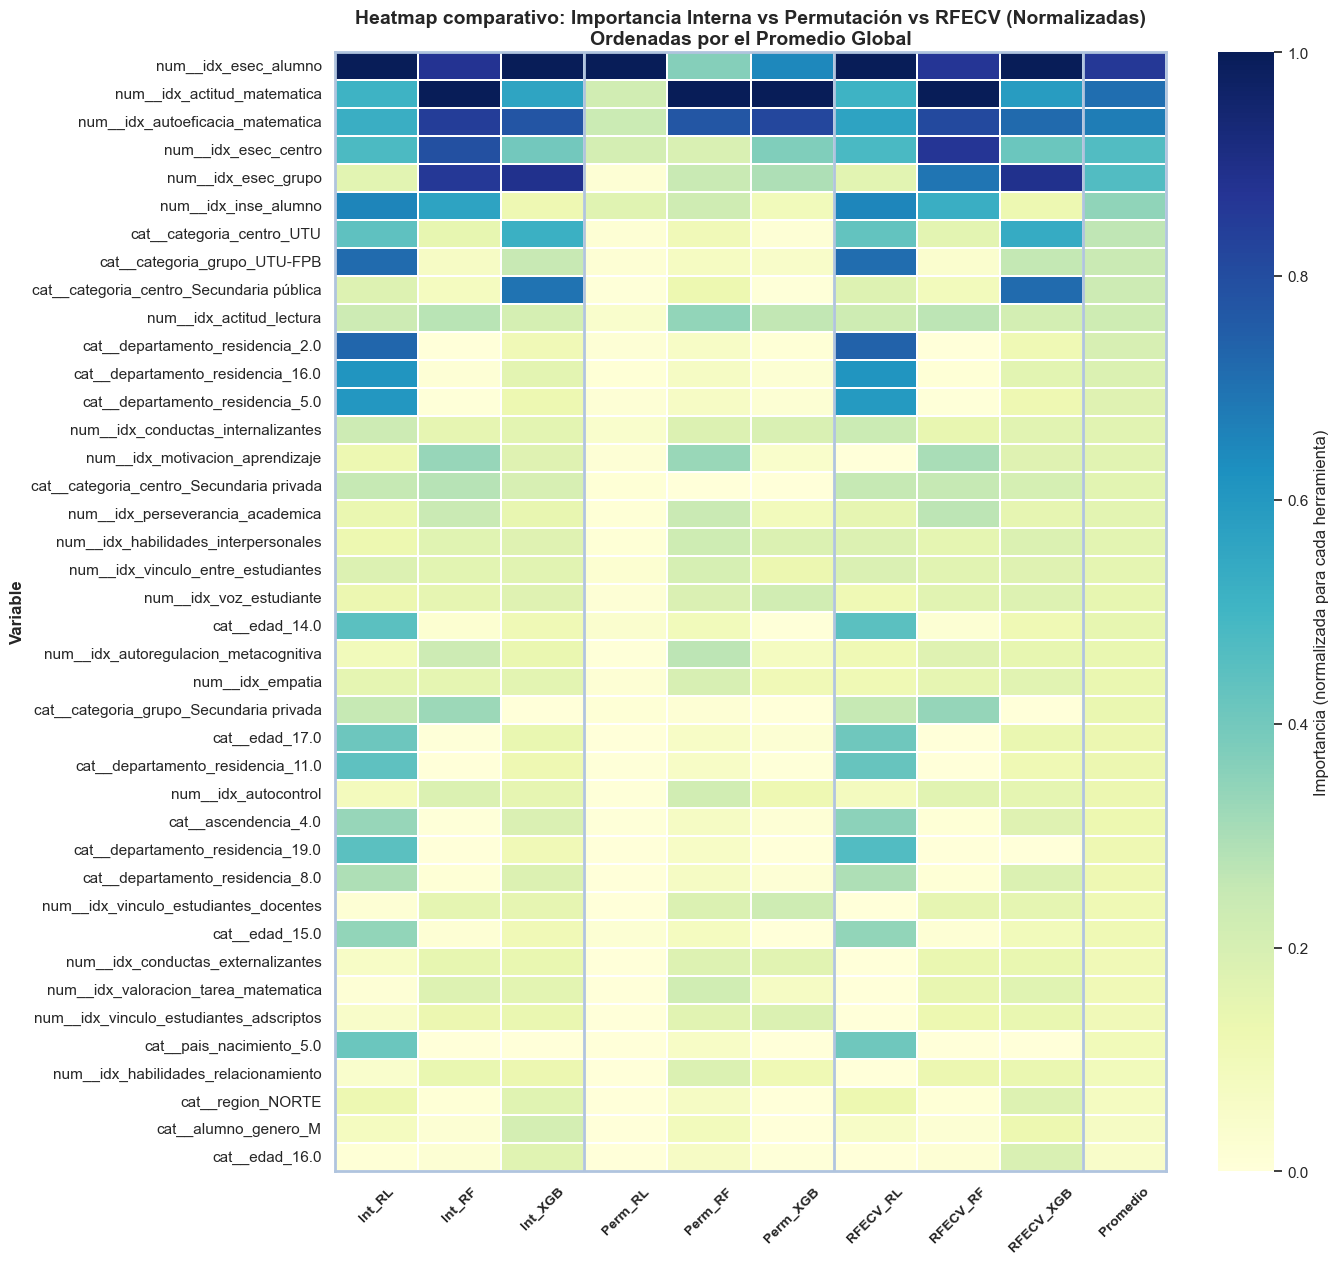

In [17]:
# =====================================================================
# FUNCIÓN FALTANTE: Normalización Min-Max
# =====================================================================
def normalizar_columna(columna):
    """
    Normaliza una columna numérica a una escala de 0 a 1.
    Si todos los valores son iguales (rango 0), devuelve la columna original
    para evitar un error de división por cero.
    """
    rango = columna.max() - columna.min()
    if rango == 0:
        return columna
    return (columna - columna.min()) / rango

# =====================================================================
# EXTRA: Preparar datos de RFECV para el Heatmap
# =====================================================================
importancias_rfecv = {}

for nombre_modelo in modelos_comparar: # Asegurate de que XGBoost esté en esta lista
    rfecv = resultados_rfecv[nombre_modelo]["selector"]
    seleccionadas = resultados_rfecv[nombre_modelo]["selected_features"]
    estimador_final = rfecv.estimator_
    
    # Extraemos importancias del modelo "limpio"
    if nombre_modelo == "Regresion_Logistica":
        imp = np.abs(estimador_final.coef_).ravel()
    else:
        imp = estimador_final.feature_importances_
        
    # Armamos una serie solo con las variables que sobrevivieron
    serie_rfecv = pd.Series(imp, index=seleccionadas)
    
    # Las variables que el RFECV eliminó no están en la serie. 
    # Al reindexar con TODAS las variables originales, aparecen como NaN. Las rellenamos con 0.
    serie_rfecv = serie_rfecv.reindex(feature_names).fillna(0)
    importancias_rfecv[nombre_modelo] = serie_rfecv

# Convertimos a DataFrame y normalizamos
df_imp_rfecv = pd.concat(importancias_rfecv, axis=1)
df_imp_rfecv_norm = df_imp_rfecv.apply(normalizar_columna, axis=0)

# -----------------------------
# 3) Heatmap comparativo normalizado (Interna + Permutación + RFECV + Promedio)
# -----------------------------
# Normalizamos para el heatmap (los dataframes anteriores)
df_imp_interna_norm = df_imp_interna.apply(normalizar_columna, axis=0)
df_imp_perm_norm = df_imp_perm.apply(normalizar_columna, axis=0)

cantidad_de_modelos = len(modelos_comparar)

# Nombres más cortos dinámicos
if cantidad_de_modelos == 3:
    df_imp_interna_norm.columns = ["Int_RL", "Int_RF", "Int_XGB"]
    df_imp_perm_norm.columns = ["Perm_RL", "Perm_RF", "Perm_XGB"]
    df_imp_rfecv_norm.columns = ["RFECV_RL", "RFECV_RF", "RFECV_XGB"]
elif cantidad_de_modelos == 2:
    df_imp_interna_norm.columns = ["Int_RL", "Int_RF"]
    df_imp_perm_norm.columns = ["Perm_RL", "Perm_RF"]
    df_imp_rfecv_norm.columns = ["RFECV_RL", "RFECV_RF"]
else:
    df_imp_interna_norm.columns = [f"Int_{modelo}" for modelo in modelos_comparar]
    df_imp_perm_norm.columns = [f"Perm_{modelo}" for modelo in modelos_comparar]
    df_imp_rfecv_norm.columns = [f"RFECV_{modelo}" for modelo in modelos_comparar]

# Concatenamos los TRES DataFrames normalizados 
# (Ej: 9 columnas en total para 3 modelos + Promedio que agregaremos luego)
df_heatmap_full = pd.concat([df_imp_interna_norm, df_imp_perm_norm, df_imp_rfecv_norm], axis=1)


# ====================================================
# VARIABLE FALTANTE: Definimos el top_n
# ====================================================
top_n = 15 # <-- ACÁ ESTÁ LA SOLUCIÓN (puedes cambiar este valor a 10 o 20)

# Extraemos el top_n de TODAS las columnas
features_heatmap = set()
for col in df_heatmap_full.columns:
    features_heatmap.update(df_heatmap_full[col].abs().sort_values(ascending=False).head(top_n).index)

df_heatmap = df_heatmap_full.loc[list(features_heatmap)].copy()

# ====================================================
# NUEVO: Calculamos y agregamos la columna del promedio
# ====================================================
# Usamos el promedio de TODOS los bloques (Int, Perm, RFECV)
# Si una variable fue eliminada en RFECV, su 0 bajará su promedio global, ¡lo cual es estadísticamente correcto!
df_heatmap["Promedio"] = df_heatmap.abs().mean(axis=1)

# Ordenamos el dataframe usando esta nueva columna
df_heatmap = df_heatmap.sort_values(by="Promedio", ascending=False)

# Graficamos
plt.figure(figsize=(14, max(8, len(df_heatmap) * 0.32))) # Agrandé un poco el ancho (figsize 14) para que entren más columnas
ax = sns.heatmap(
    df_heatmap,
    cmap="YlGnBu",
    annot=False,
    linewidths=0.3,
    cbar_kws={"label": "Importancia (normalizada para cada herramienta)"},
)

# ====================================================
# LÍNEAS DIVISORIAS VERTICALES Y BORDE
# ====================================================
color_lineas = 'lightsteelblue'

# Borde exterior del heatmap
for _, spine in ax.spines.items():
    spine.set_visible(True)
    spine.set_color(color_lineas)
    spine.set_linewidth(2)

# Separación 1: Entre Interna y Permutación
plt.axvline(x=cantidad_de_modelos, color=color_lineas, linewidth=2)

# Separación 2: Entre Permutación y RFECV
plt.axvline(x=cantidad_de_modelos*2, color=color_lineas, linewidth=2)

# Separación 3: Entre RFECV y Promedio
plt.axvline(x=cantidad_de_modelos*3, color=color_lineas, linewidth=2)


# Rotamos las etiquetas para que no se superpongan
plt.xticks(rotation=45, ha='center', fontsize=10, fontweight='bold')
#plt.yticks(fontweight='bold') 

plt.title("Heatmap comparativo: Importancia Interna vs Permutación vs RFECV (Normalizadas)\nOrdenadas por el Promedio Global", fontsize=14, fontweight='bold')
plt.ylabel("Variable", fontweight="bold")
plt.tight_layout()
plt.show()

## 5) Análisis explicativo complementario

### 5.1) Entrenamiento de árbol de decisión corto

In [ ]:
# Deshabilitar el enrutamiento estricto de Scikit-Learn
sklearn.set_config(enable_metadata_routing=False)

# Crear el pipeline para el arbol de decisión
dt_pipeline = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('clasificador', DecisionTreeClassifier(random_state=42))
])

# Definir la grilla de hiperparámetros
# Limitamos a máximo 3 niveles de profundidad para facilitar la interpretabilidad 
param_grid_dt = {
    'clasificador__max_depth': [3], 
    'clasificador__criterion': ['gini', 'entropy'],
    'clasificador__min_samples_split': [50, 100, 200],
    'clasificador__min_samples_leaf': [20, 50, 100]
}

# 3. Configurar la validación cruzada estratificada
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Configurar el GridSearchCV optimizando por ROC AUC
grid_dt = GridSearchCV(
    dt_pipeline, 
    param_grid_dt, 
    cv=cv_stratified, 
    scoring="roc_auc", 
    n_jobs=7,
    verbose=1
)

# 5. Entrenar pasando el peso DIRECTAMENTE con el nombre original (ya sin prefijos)
print("Buscando el mejor árbol de decisión sobre el dataset completo...")
grid_dt.fit(X, y, clasificador__sample_weight=w)

# 6. Extraer el mejor modelo
best_dt_pipeline = grid_dt.best_estimator_
best_dt_model = best_dt_pipeline.named_steps['clasificador']

print(f"\nMejores hiperparámetros encontrados:")
print(grid_dt.best_params_)
print(f"ROC AUC promedio en validación cruzada (5-folds): {grid_dt.best_score_:.4f}")

Buscando el mejor árbol de decisión sobre el dataset completo...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

Mejores hiperparámetros encontrados:
{'clasificador__criterion': 'gini', 'clasificador__max_depth': 3, 'clasificador__min_samples_leaf': 100, 'clasificador__min_samples_split': 50}
ROC AUC promedio en validación cruzada (5-folds): 0.8180
ROC AUC global en todo el dataset: 0.8278


### 5.2) Visualización para tomadores de decisión

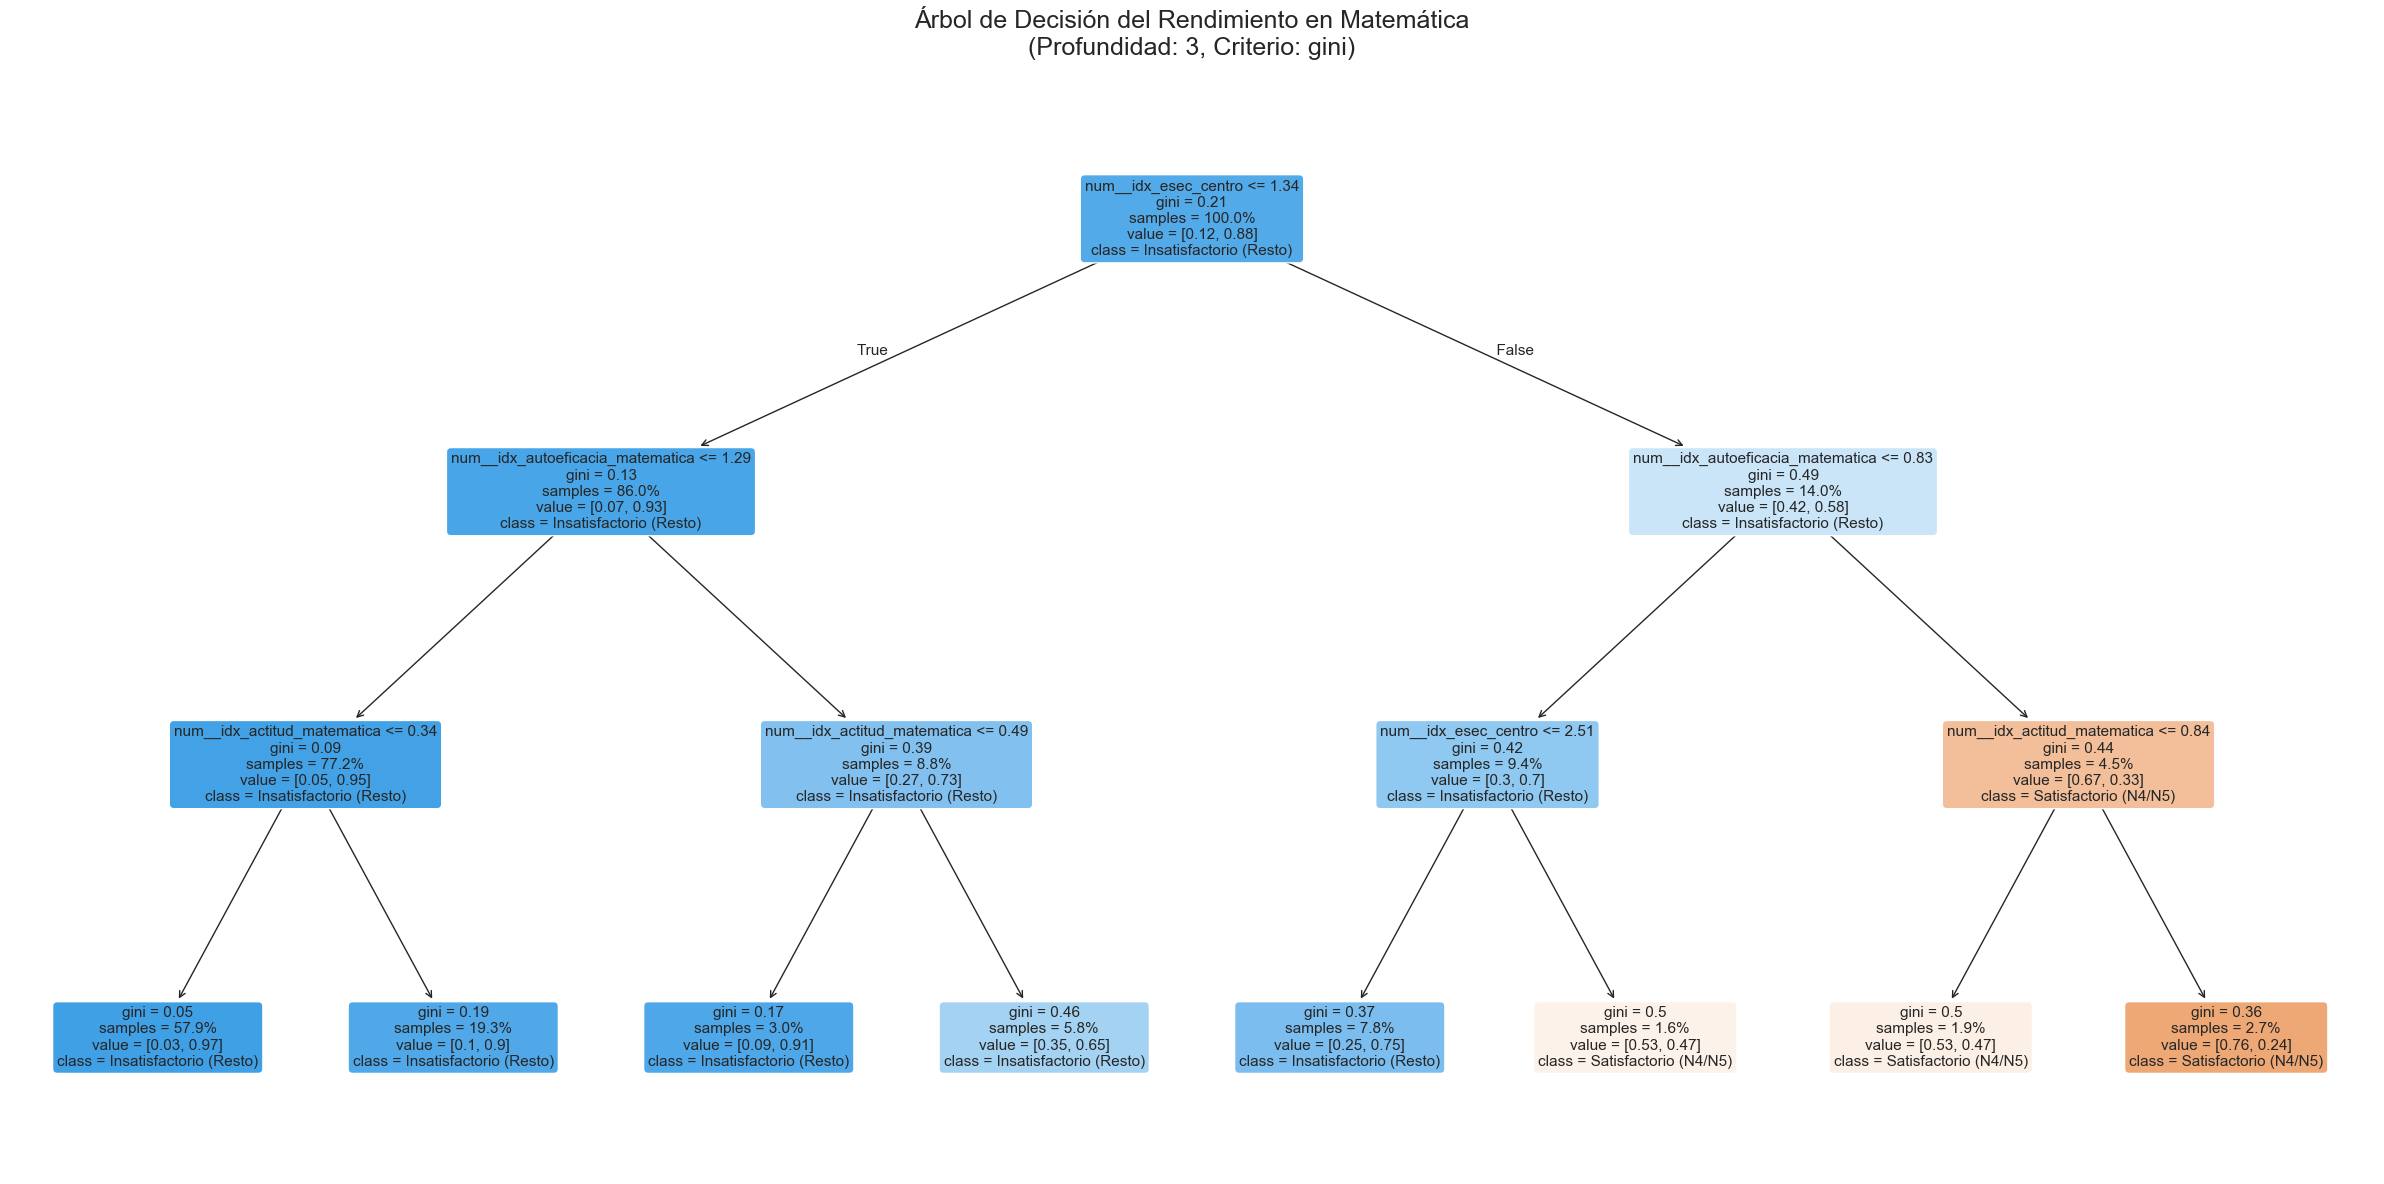

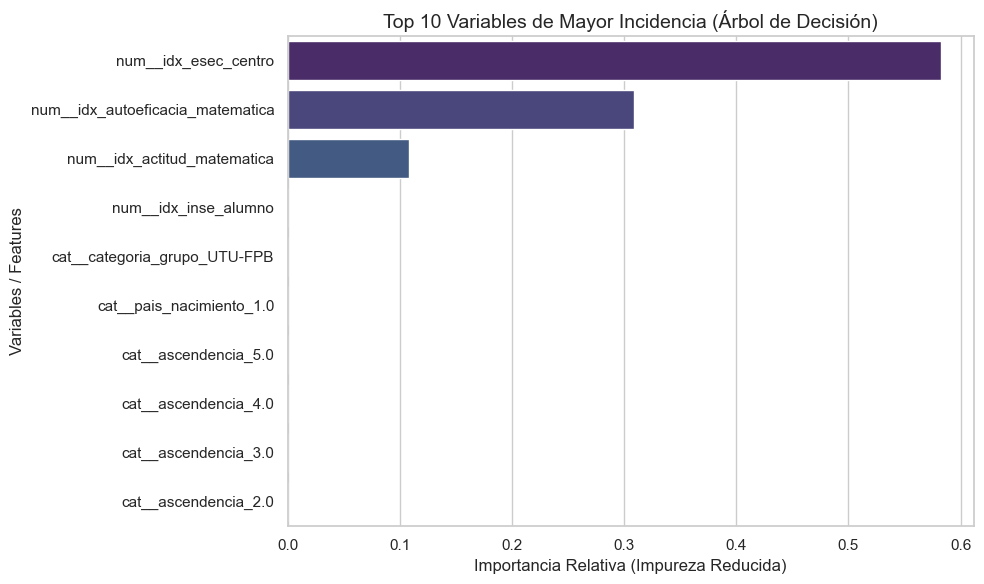

In [ ]:
# Obtener los nombres de las variables luego del preprocesamiento
feature_names = best_dt_pipeline.named_steps['preprocesamiento'].get_feature_names_out()

# Etiquetas de la variable objetivo
class_names_labels = ['Satisfactorio (N4/N5)', 'Insatisfactorio (Resto)']

# -- GRAFICAR EL ÁRBOL --
plt.figure(figsize=(24, 12))
plot_tree(
    best_dt_model,
    feature_names=feature_names,
    class_names=class_names_labels,
    filled=True,
    rounded=True,
    fontsize=11,
    proportion=True, 
    precision=2
)
plt.title(f"Árbol de Decisión del Rendimiento en Matemática\n(Profundidad: {best_dt_model.get_depth()}, Criterio: {best_dt_model.criterion})", fontsize=18, pad=20)
plt.tight_layout()
plt.show()

# -- GRAFICAR IMPORTANCIA DE VARIABLES --
importancias = best_dt_model.feature_importances_
df_importancias_dt = pd.DataFrame({'Variable': feature_names, 'Importancia': importancias})
df_importancias_dt = df_importancias_dt.sort_values(by='Importancia', ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_importancias_dt, 
    x='Importancia', 
    y='Variable', 
    hue='Variable', 
    palette='viridis', 
    legend=False
)
plt.title('Top 10 Variables de Mayor Incidencia (Árbol de Decisión)', fontsize=14)
plt.xlabel('Importancia Relativa (Impureza Reducida)')
plt.ylabel('Variables / Features')
plt.tight_layout()
plt.show()